# Are there Persistening Effects of the Berlin Divison on short-term AirBnB Market in Germany?


### Sentiment Analysis

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas
import pyproj
import rasterio
import rasterstats
import json
from rasterio.mask import mask
from rasterio.plot import show
import matplotlib.colors as pltc
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterstats import zonal_stats
from sklearn.feature_extraction.text import CountVectorizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import re
import string
from nltk.corpus import stopwords
import string
import emoji
from datetime import timedelta

In [2]:
data_dir =r"/Users/mc127/Box/ACE_592_SAE/ACE_592_SAE/Sentiment_Analysis_Sharanya/"

In [3]:
df = pd.read_csv(data_dir+"merged_airbnb.csv")
df.head(5)

,id,geometry,region,distance_to_wall_m,borough,listing_url,scrape_id,last_scraped,source,name,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,3176,POINT (13.4181 52.53471),East Berlin,1161.272256,Pankow,https://www.airbnb.com/rooms/3176,2.024122e+13,2024-12-21,city scrape,Fabulous Flat in great Location,...,4.69,4.92,4.62,First name and Last name: Nicolas Krotz <br/> ...,f,1.0,1.0,0.0,0.0,0.78
1,9991,POINT (13.41805 52.53269),East Berlin,1291.171194,Pankow,https://www.airbnb.com/rooms/9991,2.024122e+13,2024-12-21,city scrape,Geourgeous flat - outstanding views,...,5.00,4.86,4.86,03/Z/RA/003410-18,f,1.0,1.0,0.0,0.0,0.06
2,14325,POINT (13.40366 52.54813),East Berlin,260.201295,Pankow,https://www.airbnb.com/rooms/14325,2.024122e+13,2024-12-21,city scrape,Studio Apartment in Prenzlauer Berg,...,4.85,4.60,4.45,NaN,f,4.0,4.0,0.0,0.0,0.15
3,16644,POINT (13.43508 52.50312),West Berlin,357.694043,Friedrichshain-Kreuzberg,https://www.airbnb.com/rooms/16644,2.024122e+13,2024-12-21,city scrape,In the Heart of Berlin - Kreuzberg,...,4.86,4.67,4.71,NaN,f,2.0,2.0,0.0,0.0,0.27
4,17904,POINT (13.42166 52.49419),West Berlin,1142.908319,Neukölln,https://www.airbnb.com/rooms/17904,2.024122e+13,2024-12-21,city scrape,Beautiful Kreuzberg studio - 3 months minimum,...,4.92,4.87,4.65,NaN,f,1.0,1.0,0.0,0.0,1.65


In [4]:
print(df.columns)

Index(['id', 'geometry', 'region', 'distance_to_wall_m', 'borough',
       'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 

In [5]:
df = df[['id','geometry', 'region','distance_to_wall_m','name','description', 'neighborhood_overview','amenities','price','review_scores_rating']]
df.head(5)

,id,geometry,region,distance_to_wall_m,name,description,neighborhood_overview,amenities,price,review_scores_rating
0,3176,POINT (13.4181 52.53471),East Berlin,1161.272256,Fabulous Flat in great Location,This beautiful first floor apartment is situa...,The neighbourhood is famous for its variety of...,"[""Private hot tub"", ""Wine glasses"", ""Coffee"", ...",$95.00,4.63
1,9991,POINT (13.41805 52.53269),East Berlin,1291.171194,Geourgeous flat - outstanding views,4 bedroom with very large windows and outstand...,Prenzlauer Berg is an amazing neighbourhood wh...,"[""Kitchen"", ""Room-darkening shades"", ""Bed line...",$180.00,5.00
2,14325,POINT (13.40366 52.54813),East Berlin,260.201295,Studio Apartment in Prenzlauer Berg,The apartment is located on the upper second f...,NaN,"[""Coffee maker"", ""Kitchen"", ""Hangers"", ""Smoke ...",$75.00,4.68
3,16644,POINT (13.43508 52.50312),West Berlin,357.694043,In the Heart of Berlin - Kreuzberg,Light and sunny 2-Room-turn of the century-fla...,Our Part of Kreuzberg is just the best. Good v...,"[""Hair dryer"", ""Kitchen"", ""Room-darkening shad...",$90.00,4.72
4,17904,POINT (13.42166 52.49419),West Berlin,1142.908319,Beautiful Kreuzberg studio - 3 months minimum,"- apt is available starting September 1, 2024<...","The apartment is located in Kreuzberg, which i...","[""Kitchen"", ""Shampoo"", ""Dishes and silverware""...",$28.00,4.77


In [6]:
df_r=df[['id','geometry','region','distance_to_wall_m','price','review_scores_rating']]

In [7]:
df_d = pd.read_csv(data_dir+"reviews_det.csv")
print(df_d)

                 listing_id                   id        date  reviewer_id  \
0                      3176                 4283  2009-06-20        21475   
1                      3176               134722  2010-11-07       263467   
2                      3176               144064  2010-11-24        76726   
3                      3176               156702  2010-12-21       291657   
4                      3176               165048  2011-01-04       279789   
...                     ...                  ...         ...          ...   
572278  1313993831773541440  1315925029743660294  2024-12-20    446129539   
572279  1281176035638399404  1306438130581878440  2024-12-07    465886467   
572280  1281201367016682094  1297770900859161082  2024-11-25     60336420   
572281  1281201367016682094  1301378178133331066  2024-11-30    153420827   
572282  1281854006835878601  1307175863812993640  2024-12-08     61484056   

       reviewer_name                                           comments  
0

In [8]:
# Drop duplicates based on 'comments', 'reviewer_id', 'listing_id', and 'id'
df_d = df_d.drop_duplicates(subset=['comments', 'reviewer_id', 'listing_id', 'id'], keep='first')

# Check the result
print(df_d)


                 listing_id                   id        date  reviewer_id  \
0                      3176                 4283  2009-06-20        21475   
1                      3176               134722  2010-11-07       263467   
2                      3176               144064  2010-11-24        76726   
3                      3176               156702  2010-12-21       291657   
4                      3176               165048  2011-01-04       279789   
...                     ...                  ...         ...          ...   
572278  1313993831773541440  1315925029743660294  2024-12-20    446129539   
572279  1281176035638399404  1306438130581878440  2024-12-07    465886467   
572280  1281201367016682094  1297770900859161082  2024-11-25     60336420   
572281  1281201367016682094  1301378178133331066  2024-11-30    153420827   
572282  1281854006835878601  1307175863812993640  2024-12-08     61484056   

       reviewer_name                                           comments  
0

In [9]:
df_d = df_d[['listing_id','comments']]
df_d.head(5)

,listing_id,comments
0,3176,"excellent stay, i would highly recommend it. a..."
1,3176,Britta's apartment in Berlin is in a great are...
2,3176,"Fantastic, large place in good location. Only ..."
3,3176,L'appartamento di Britta è molto largo carino ...
4,3176,We went in Berlin for the new year eve. The ap...


In [10]:
df_d = df_d.rename(columns={'listing_id': 'id'})
df_d.head(5)

,id,comments
0,3176,"excellent stay, i would highly recommend it. a..."
1,3176,Britta's apartment in Berlin is in a great are...
2,3176,"Fantastic, large place in good location. Only ..."
3,3176,L'appartamento di Britta è molto largo carino ...
4,3176,We went in Berlin for the new year eve. The ap...


In [11]:
merged_df = pd.merge(df_r, df_d, on='id', how='inner')


In [12]:
print(merged_df.head(7))

     id                  geometry       region  distance_to_wall_m   price  \
0  3176  POINT (13.4181 52.53471)  East Berlin         1161.272256  $95.00   
1  3176  POINT (13.4181 52.53471)  East Berlin         1161.272256  $95.00   
2  3176  POINT (13.4181 52.53471)  East Berlin         1161.272256  $95.00   
3  3176  POINT (13.4181 52.53471)  East Berlin         1161.272256  $95.00   
4  3176  POINT (13.4181 52.53471)  East Berlin         1161.272256  $95.00   
5  3176  POINT (13.4181 52.53471)  East Berlin         1161.272256  $95.00   
6  3176  POINT (13.4181 52.53471)  East Berlin         1161.272256  $95.00   

   review_scores_rating                                           comments  
0                  4.63  excellent stay, i would highly recommend it. a...  
1                  4.63  Britta's apartment in Berlin is in a great are...  
2                  4.63  Fantastic, large place in good location. Only ...  
3                  4.63  L'appartamento di Britta è molto largo car

In [13]:
merged_df[merged_df['comments'].duplicated(keep=False)][['comments']]


,comments
0,"excellent stay, i would highly recommend it. a..."
1,Britta's apartment in Berlin is in a great are...
2,"Fantastic, large place in good location. Only ..."
3,L'appartamento di Britta è molto largo carino ...
4,We went in Berlin for the new year eve. The ap...
...,...
2228618,War sehr angenehm
2228636,Danke für den angenehmen Aufenthalt.
2228642,"Alles top, gerne wieder!"
2228653,Perfect


### Sentiment Analysis of Reviews

In [14]:
import string
string.punctuation

# This maketrans function can be used to remove a list of characters from a string.
remv_punc = str.maketrans('','',string.punctuation + '“' +"‘"+'”')
# Make the text lowercase, then replace "\n" with white space " "

merged_df['cmnts_lower'] =  merged_df['comments'].str.lower().str.replace("\n"," ")
merged_df['cmnts_clean'] = merged_df.cmnts_lower.str.translate(remv_punc)
merged_df['cmnts_clean'] = merged_df['cmnts_clean'].fillna('')

In [15]:
from nltk.corpus import stopwords
# Download the stopwords, but add another list with "amp", "", and white space " "
eng_stop = stopwords.words('english')
ger_stop = stopwords.words('german')
custom_stop = ['amp', '', ' ']  # add more if needed
all_stopwords = eng_stop + ger_stop + custom_stop

# For each tweet text, split on the whitespace to get a list of words
merged_df['cmnts_words'] = [x.split(" ") for x in merged_df['cmnts_clean']]


# Convert the text to a set, subtract the set of stopwords, turn into list
merged_df['cmnts_words'] = [list(set(x) - set(all_stopwords )) for x in merged_df['cmnts_words']]


In [16]:
from sklearn.feature_extraction.text import CountVectorizer
vct = CountVectorizer(stop_words=all_stopwords )
X = vct.fit_transform(list(merged_df['cmnts_clean']))
X
word_counts = pd.DataFrame(X.sum(axis=0))
word_counts.columns = vct.get_feature_names_out()
word_counts = word_counts.T
word_counts[0].sort_values(ascending=False).head(20)

great         672016
apartment     612640
stay          534776
place         533867
berlin        513483
location      411797
nice          373083
super         366997
clean         345666
de            299897
host          284726
wohnung       278406
good          259342
would         249710
recommend     247281
really        234718
everything    227574
easy          195579
us            194266
well          191772
Name: 0, dtype: int64

In [17]:
# Subset data East vs West of Wall
east_df = merged_df[merged_df['region'] == 'East Berlin']
west_df = merged_df[merged_df['region'] == 'West Berlin']

# CountVectorizer for East
X_east = vct.fit_transform(list(east_df['cmnts_clean']))
east_counts = pd.DataFrame(X_east.sum(axis=0))
east_counts.columns = vct.get_feature_names_out()
east_counts = east_counts.T
print("Top 10 East words:")
print(east_counts[0].sort_values(ascending=False).head(10))

# CountVectorizer for West
X_west = vct.fit_transform(list(west_df['cmnts_clean']))
west_counts = pd.DataFrame(X_west.sum(axis=0))
west_counts.columns = vct.get_feature_names_out()
west_counts = west_counts.T
print("\nTop 10 West words:")
print(west_counts[0].sort_values(ascending=False).head(10))


Top 10 East words:
great        347775
apartment    318435
stay         268329
berlin       263112
place        261397
location     228143
nice         182942
super        180318
clean        174486
de           152913
Name: 0, dtype: int64

Top 10 West words:
great        324202
apartment    294189
place        272356
stay         266374
berlin       250163
nice         190095
super        186480
location     183630
clean        171150
host         147533
Name: 0, dtype: int64


In [18]:
from sklearn.feature_extraction import text 
custom_stop_words = ['apartment', 'house', 'place', 'berlin', 'germany', 'host', 'stay' ,'location', 'wohnung', 'really', 'room']

english_stop_words = set(text.ENGLISH_STOP_WORDS)
german_stop_words = set(stopwords.words('german'))

# Combine all stop words
all_stop_words = list(english_stop_words.union(german_stop_words).union(custom_stop_words))

vct_csw = CountVectorizer(stop_words=all_stop_words)

# CountVectorizer for East
X_east_csw = vct_csw.fit_transform(list(east_df['cmnts_clean']))
east_counts_csw = pd.DataFrame(X_east_csw.sum(axis=0))
east_counts_csw.columns = vct_csw.get_feature_names_out()
east_counts_csw = east_counts_csw.T
print("Top 10 East words:")
print(east_counts_csw[0].sort_values(ascending=False).head(10))

# CountVectorizer for West
X_west_csw = vct_csw.fit_transform(list(west_df['cmnts_clean']))
west_counts_csw = pd.DataFrame(X_west_csw.sum(axis=0))
west_counts_csw.columns = vct_csw.get_feature_names_out()
west_counts_csw = west_counts_csw.T
print("\nTop 10 West words:")
print(west_counts_csw[0].sort_values(ascending=False).head(10))

Top 10 East words:
great          347775
nice           182942
super          180318
clean          174486
good           127871
recommend      124813
restaurants    102278
perfect        100549
easy            98484
close           93197
Name: 0, dtype: int64

Top 10 West words:
great          324202
nice           190095
super          186480
clean          171150
good           131464
recommend      122409
easy            97071
close           93188
comfortable     91349
perfect         90763
Name: 0, dtype: int64


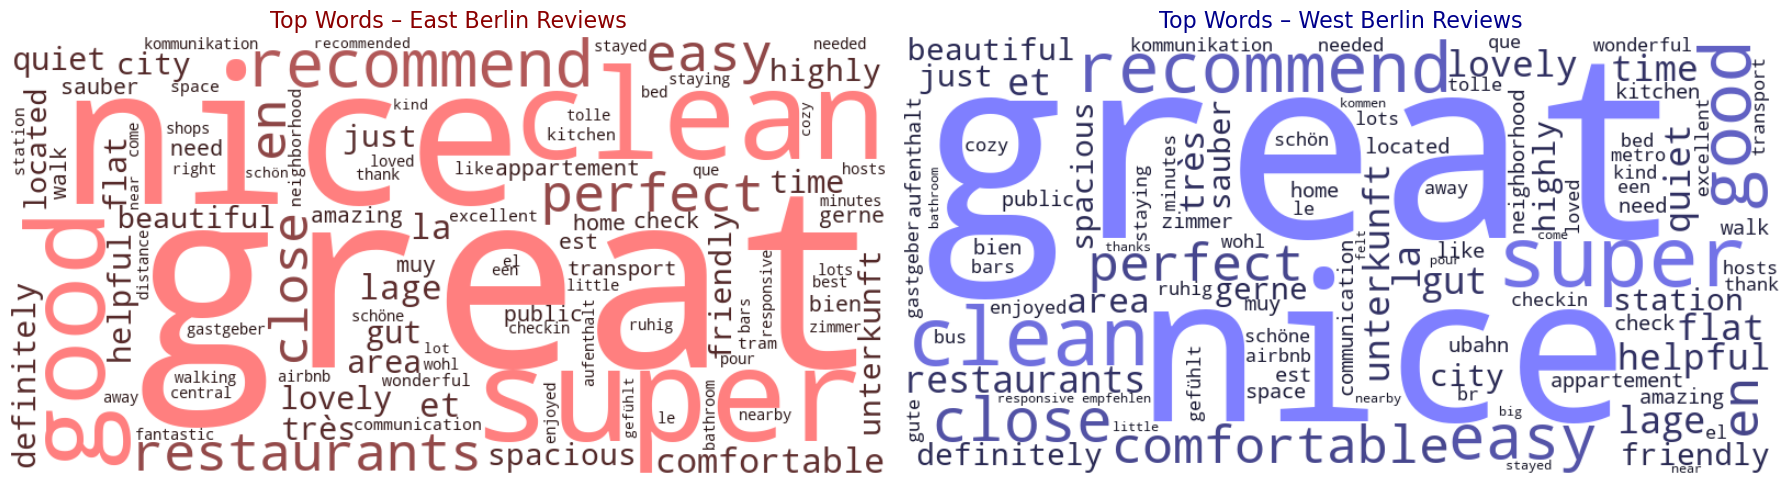

In [19]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Step 1: Convert word frequencies to dictionaries
east_freq_dict = east_counts_csw[0].to_dict()
west_freq_dict = west_counts_csw[0].to_dict()

# Step 2: Custom color functions
def red_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    # Bigger = darker red
    red = min(255, font_size * 3)
    return f"rgb({red}, {int(red*0.5)}, {int(red*0.5)})"

def blue_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    # Bigger = darker blue
    blue = min(255, font_size * 3)
    return f"rgb({int(blue*0.5)}, {int(blue*0.5)}, {blue})"

# Step 3: Generate word clouds
wc_east = WordCloud(width=800, height=400, background_color='white',
                    color_func=red_color_func,max_words=100).generate_from_frequencies(east_freq_dict)

wc_west = WordCloud(width=800, height=400, background_color='white',
                    color_func=blue_color_func,max_words=100).generate_from_frequencies(west_freq_dict)

# Step 4: Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

ax1.imshow(wc_east, interpolation='bilinear')
ax1.set_title("Top Words – East Berlin Reviews", fontsize=16, color='darkred')
ax1.axis('off')

ax2.imshow(wc_west, interpolation='bilinear')
ax2.set_title("Top Words – West Berlin Reviews", fontsize=16, color='darkblue')
ax2.axis('off')

plt.tight_layout()
plt.show()

# Save the combined figure
fig.savefig("berlin_wordclouds_east_vs_west_reviews.png", dpi=300, bbox_inches='tight')


In [20]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# Download VADER if not already
nltk.download('vader_lexicon')

# Step 1: Initialize the analyzer
sia = SentimentIntensityAnalyzer()

# Step 2: Compute sentiment score for each review
merged_df['sentiment'] = merged_df['cmnts_clean'].apply(lambda x: sia.polarity_scores(x)['compound'])

# Step 3: Filter by region
east_reviews = merged_df[merged_df['region'] == 'East Berlin']
west_reviews = merged_df[merged_df['region'] == 'West Berlin']

# Step 4: Sort reviews by sentiment
east_reviews = east_reviews.drop_duplicates(subset='comments')
west_reviews = west_reviews.drop_duplicates(subset='comments')

most_positive_east = east_reviews.sort_values(by='sentiment', ascending=False).head(5)
most_negative_east = east_reviews.sort_values(by='sentiment').head(5)

most_positive_west = west_reviews.sort_values(by='sentiment', ascending=False).head(5)
most_negative_west = west_reviews.sort_values(by='sentiment').head(5)

# Step 5: Display Results
def print_top_reviews(df_subset, title):
    print(f"\n{title}")
    print("-" * 60)
    for i, row in df_subset.iterrows():
        print(f"Review: {row['comments']}")
        print(f"Sentiment Score: {row['sentiment']}")
        print("-" * 60)

# East
print_top_reviews(most_positive_east, "Top 5 Positive Reviews – East")
print_top_reviews(most_negative_east, "Top 5 Negative Reviews – East")

# West
print_top_reviews(most_positive_west, "Top 5 Positive Reviews – West")
print_top_reviews(most_negative_west, "Top 5 Negative Reviews – West")


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\mc127\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!



Top 5 Positive Reviews – East
------------------------------------------------------------
Review: We had a really great 8-night stay.  From the first minute of inquiry, I could tell that the hosts were great.  They were very quick to respond to inquiries.  Good communication makes a huge difference to me.  Our flight was delayed by 7 hours, which required adjusting who was available to meet us at the apartment, but Sven was extremely gracious about the inconvenience to them and quickly arranged another person to tend to us during the week, and Shpresa was the perfect balance of friendly, quick to reply, and conveniently available when needed.  Great thanks to her for being available on short notice and helping us when needed.<br/>The apartment is exactly as pictured.  The main living area has very large windows with great views onto the cityscape below.  The two double-bed rooms are facing the back of the building, which is very quiet.  I am particular about noise, and I was very ple

In [21]:
average_sentiment = merged_df['sentiment'].median()
merged_df['price2'] = merged_df['price'].replace('[\$,]', '', regex=True).astype(float)
avg_price_positive_sentiment = merged_df[merged_df['sentiment'] > 0]['price2'].median()
avg_price_negative_sentiment = merged_df[merged_df['sentiment'] < 0]['price2'].median()


print(average_sentiment)
print(avg_price_positive_sentiment)
print(avg_price_negative_sentiment)


<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
C:\Users\mc127\AppData\Local\Temp\ipykernel_55332\2656281175.py:2: SyntaxWarning: invalid escape sequence '\$'
  merged_df['price2'] = merged_df['price'].replace('[\$,]', '', regex=True).astype(float)


0.6249
96.0
90.0


In [22]:
e_average_sentiment = east_reviews['sentiment'].median()
east_reviews['price2'] = east_reviews['price'].replace('[\$,]', '', regex=True).astype(float)
e_avg_price_positive_sentiment = east_reviews[east_reviews['sentiment'] > 0]['price2'].median()
e_avg_price_negative_sentiment = east_reviews[east_reviews['sentiment'] < 0]['price2'].median()


print(e_average_sentiment)
print(e_avg_price_positive_sentiment)
print(e_avg_price_negative_sentiment)


<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
C:\Users\mc127\AppData\Local\Temp\ipykernel_55332\1291762111.py:2: SyntaxWarning: invalid escape sequence '\$'
  east_reviews['price2'] = east_reviews['price'].replace('[\$,]', '', regex=True).astype(float)


0.6908
100.0
95.0


In [23]:
w_average_sentiment = west_reviews['sentiment'].median()
west_reviews['price2'] = west_reviews['price'].replace('[\$,]', '', regex=True).astype(float)
w_avg_price_positive_sentiment = west_reviews[west_reviews['sentiment'] > 0]['price2'].median()
w_avg_price_negative_sentiment = west_reviews[west_reviews['sentiment'] < 0]['price2'].median()


print(w_average_sentiment)
print(w_avg_price_positive_sentiment)
print(w_avg_price_negative_sentiment)


<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
C:\Users\mc127\AppData\Local\Temp\ipykernel_55332\2178471210.py:2: SyntaxWarning: invalid escape sequence '\$'
  west_reviews['price2'] = west_reviews['price'].replace('[\$,]', '', regex=True).astype(float)


0.6249
90.0
85.0


In [24]:
# Select relevant columns for the summary table
cols_to_show = ['comments', 'sentiment', 'review_scores_rating','price']

# Round sentiment scores for readability
most_positive_east['sentiment'] = most_positive_east['sentiment']
most_negative_east['sentiment'] = most_negative_east['sentiment']
most_positive_west['sentiment'] = most_positive_west['sentiment']
most_negative_west['sentiment'] = most_negative_west['sentiment']

# Display tables
print("Top 5 Positive Reviews – East Berlin")
display(most_positive_east[cols_to_show].reset_index(drop=True))

print("Top 5 Negative Reviews – East Berlin")
display(most_negative_east[cols_to_show].reset_index(drop=True))

print("Top 5 Positive Reviews – West Berlin")
display(most_positive_west[cols_to_show].reset_index(drop=True))

print("Top 5 Negative Reviews – West Berlin")
display(most_negative_west[cols_to_show].reset_index(drop=True))


Top 5 Positive Reviews – East Berlin


,comments,sentiment,review_scores_rating,price
0,We had a really great 8-night stay. From the ...,0.9994,4.88,$350.00
1,Aglaja was a great host from the very start. T...,0.9994,4.82,$145.00
2,Of all the airbnbs / vacation rentals I have s...,0.9992,4.83,$55.00
3,If you are not really in to sleeping or taking...,0.9991,4.70,$159.00
4,I have stayed at Benjamin’s apartment for appr...,0.9991,4.93,$55.00


Top 5 Negative Reviews – East Berlin


,comments,sentiment,review_scores_rating,price
0,Mein Kumpel und ich haben Jan's Apartment für ...,-0.9990,4.81,$106.00
1,Vor dem Buchen habe ich leider keinen Hinweis ...,-0.9988,4.78,$87.00
2,"Pro:<br/>Self Check In lief super ab, die Gast...",-0.9985,4.20,$96.00
3,Holger und Bettina sind wirklich sehr nette Ga...,-0.9983,4.73,$119.00
4,Das wichtigste zu erst: Ich habe mein Geld zur...,-0.9982,4.75,$43.00


Top 5 Positive Reviews – West Berlin


,comments,sentiment,review_scores_rating,price
0,"Dear Elisa and Dear Francesco,\r<br/>\r<br/>Fi...",0.9992,4.81,$79.00
1,"Samira is a very friendly, considerate and hel...",0.9992,5.00,$58.00
2,"If you ever wondered if angels exist, they do,...",0.9992,4.87,$62.00
3,We stayed at Christoph’s flat for 5 nights and...,0.9991,4.83,NaN
4,The Place was great. Supper nice location and ...,0.9989,4.87,$90.00


Top 5 Negative Reviews – West Berlin


,comments,sentiment,review_scores_rating,price
0,Die Kommunikation mit Lisa war gut. Lisa war i...,-0.9993,4.67,$89.00
1,Vorteile: <br/>-Stephan war unglaublich hilfre...,-0.9985,4.36,$90.00
2,"Mit fünf Freunden, die sich aufgrund der Pande...",-0.9984,4.87,$477.00
3,Die Begrüßung der Hausherrin war wenig herzlic...,-0.9982,4.68,$101.00
4,Zunächst war die Kontaktaufnahme mit einem Mit...,-0.9981,4.58,$109.00


In [25]:
merged_df.head()

,id,geometry,region,distance_to_wall_m,price,review_scores_rating,comments,cmnts_lower,cmnts_clean,cmnts_words,sentiment,price2
0,3176,POINT (13.4181 52.53471),East Berlin,1161.272256,$95.00,4.63,"excellent stay, i would highly recommend it. a...","excellent stay, i would highly recommend it. a...",excellent stay i would highly recommend it a n...,"[clear, recommend, instructions, britta, flat,...",0.9608,95.0
1,3176,POINT (13.4181 52.53471),East Berlin,1161.272256,$95.00,4.63,Britta's apartment in Berlin is in a great are...,britta's apartment in berlin is in a great are...,brittas apartment in berlin is in a great area...,"[apartment, stay, access, berlin, restaurants,...",0.9403,95.0
2,3176,POINT (13.4181 52.53471),East Berlin,1161.272256,$95.00,4.63,"Fantastic, large place in good location. Only ...","fantastic, large place in good location. only ...",fantastic large place in good location only a ...,"[regarding, gargerin, ride, good, cafe, apartm...",0.9545,95.0
3,3176,POINT (13.4181 52.53471),East Berlin,1161.272256,$95.00,4.63,L'appartamento di Britta è molto largo carino ...,l'appartamento di britta è molto largo carino ...,lappartamento di britta è molto largo carino c...,"[la, molto, è, dove, mangiare, lappartamento, ...",0.0000,95.0
4,3176,POINT (13.4181 52.53471),East Berlin,1161.272256,$95.00,4.63,We went in Berlin for the new year eve. The ap...,we went in berlin for the new year eve. the ap...,we went in berlin for the new year eve the app...,"[appartment, amazing, year, cool, berlin, brit...",0.9048,95.0


In [26]:
from shapely import wkt

merged_df['geometry'] = merged_df['geometry'].apply(wkt.loads)

import geopandas as gpd
from shapely.geometry import Point


merged_gdf = gpd.GeoDataFrame(merged_df, geometry='geometry', crs='EPSG:4326')  

print(type(merged_gdf))
print(merged_gdf.geometry.head())
# this file is now ready to be plot
# still need other base layers as map of berlin
print(type(merged_gdf))
print(merged_gdf.geometry.head())
# this file is now ready to be plot
# still need other base layers as map of berlin

dividing_line = geopandas.read_file(data_dir+"/dividing_line.json")
east_berlin = geopandas.read_file(data_dir+"/east_berlin.json")
west_berlin = geopandas.read_file(data_dir+"/west_berlin.json")

<class 'geopandas.geodataframe.GeoDataFrame'>
0    POINT (13.4181 52.53471)
1    POINT (13.4181 52.53471)
2    POINT (13.4181 52.53471)
3    POINT (13.4181 52.53471)
4    POINT (13.4181 52.53471)
Name: geometry, dtype: geometry
<class 'geopandas.geodataframe.GeoDataFrame'>
0    POINT (13.4181 52.53471)
1    POINT (13.4181 52.53471)
2    POINT (13.4181 52.53471)
3    POINT (13.4181 52.53471)
4    POINT (13.4181 52.53471)
Name: geometry, dtype: geometry


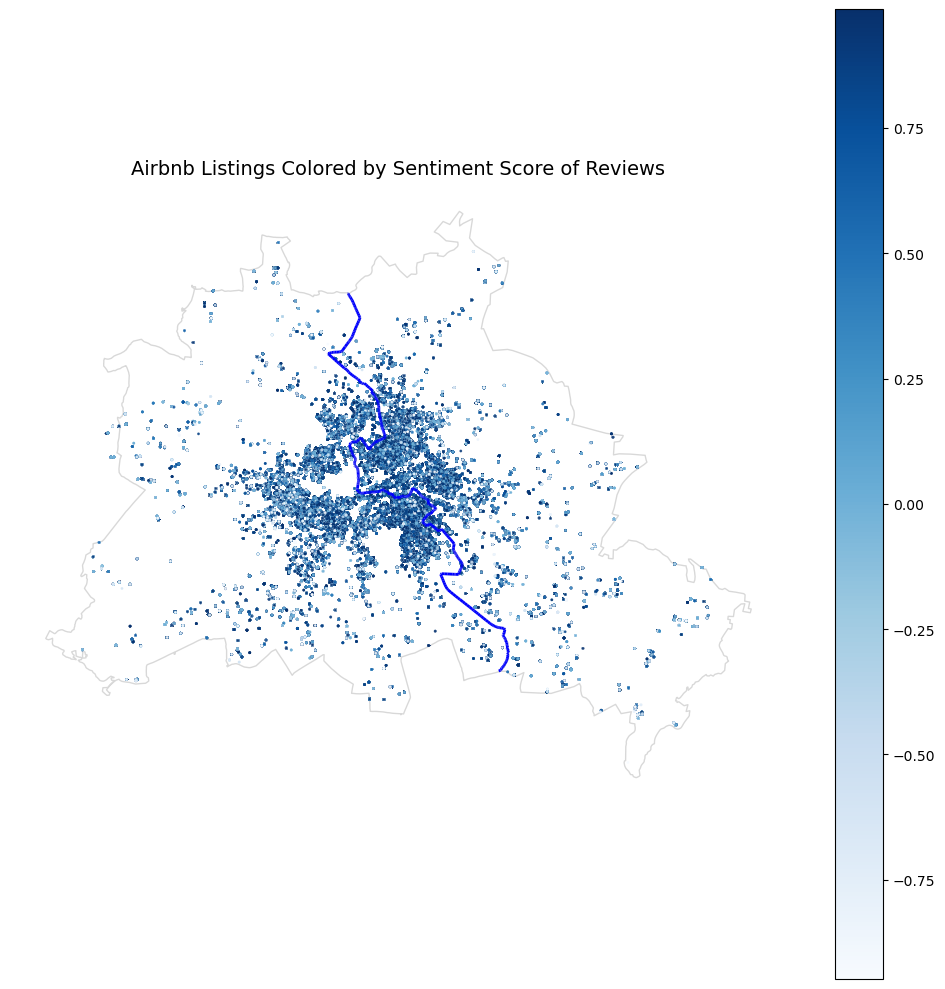

In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

east_berlin.plot(ax=ax, facecolor='white', edgecolor='grey', alpha=0.3)
west_berlin.plot(ax=ax, facecolor='white', edgecolor='grey', alpha=0.3)
dividing_line.plot(ax=ax, color='blue', linewidth=2)

# Normalize sentiment if needed
vmin = merged_gdf['sentiment'].quantile(0.02)
vmax = merged_gdf['sentiment'].quantile(0.98)

# Plot sentiment scores
merged_gdf.plot(
    ax=ax,
    column='sentiment',
    cmap='Blues',       
    markersize=1,
    legend=True,
    alpha=0.8,
    vmin=vmin,
    vmax=vmax
)

ax.set_title("Airbnb Listings Colored by Sentiment Score of Reviews", fontsize=14)
ax.axis("off")

plt.tight_layout()

plt.savefig("airbnb_sentiment_map_reviews.png", dpi=300, bbox_inches='tight')

plt.show()


In [28]:
# Clean price column
merged_df['price_clean'] = merged_df['price'].replace('[\$,]', '', regex=True).astype(float)

# Now create a DataFrame with just the relevant columns
price_and_sent = merged_df[['sentiment', 'price_clean']]

# Compute correlation matrix
correlation_matrix = price_and_sent.corr()
print(correlation_matrix)


<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
C:\Users\mc127\AppData\Local\Temp\ipykernel_55332\1610565820.py:2: SyntaxWarning: invalid escape sequence '\$'
  merged_df['price_clean'] = merged_df['price'].replace('[\$,]', '', regex=True).astype(float)


             sentiment  price_clean
sentiment       1.0000       0.0595
price_clean     0.0595       1.0000


In [29]:
df.head()

,id,geometry,region,distance_to_wall_m,name,description,neighborhood_overview,amenities,price,review_scores_rating
0,3176,POINT (13.4181 52.53471),East Berlin,1161.272256,Fabulous Flat in great Location,This beautiful first floor apartment is situa...,The neighbourhood is famous for its variety of...,"[""Private hot tub"", ""Wine glasses"", ""Coffee"", ...",$95.00,4.63
1,9991,POINT (13.41805 52.53269),East Berlin,1291.171194,Geourgeous flat - outstanding views,4 bedroom with very large windows and outstand...,Prenzlauer Berg is an amazing neighbourhood wh...,"[""Kitchen"", ""Room-darkening shades"", ""Bed line...",$180.00,5.00
2,14325,POINT (13.40366 52.54813),East Berlin,260.201295,Studio Apartment in Prenzlauer Berg,The apartment is located on the upper second f...,NaN,"[""Coffee maker"", ""Kitchen"", ""Hangers"", ""Smoke ...",$75.00,4.68
3,16644,POINT (13.43508 52.50312),West Berlin,357.694043,In the Heart of Berlin - Kreuzberg,Light and sunny 2-Room-turn of the century-fla...,Our Part of Kreuzberg is just the best. Good v...,"[""Hair dryer"", ""Kitchen"", ""Room-darkening shad...",$90.00,4.72
4,17904,POINT (13.42166 52.49419),West Berlin,1142.908319,Beautiful Kreuzberg studio - 3 months minimum,"- apt is available starting September 1, 2024<...","The apartment is located in Kreuzberg, which i...","[""Kitchen"", ""Shampoo"", ""Dishes and silverware""...",$28.00,4.77


### Sentiment Analysis of Amenities

In [30]:
import string
string.punctuation

# This maketrans function can be used to remove a list of characters from a string.
remv_punc = str.maketrans('','',string.punctuation + '“' +"‘"+'”')
# Make the text lowercase, then replace "\n" with white space " "

df['amenities_lower'] =  df['amenities'].str.lower().str.replace("\n"," ")
df['amenities_clean'] = df.amenities_lower.str.translate(remv_punc)
df['amenities_clean'] = df['amenities_clean'].fillna('') 

In [31]:
from nltk.corpus import stopwords
# Download the stopwords, but add another list with "amp", "", and white space " "
eng_stop = stopwords.words('english')
ger_stop = stopwords.words('german')
custom_stop = ['amp', '', ' ']  # add more if needed
all_stopwords = eng_stop + ger_stop + custom_stop

# For each tweet text, split on the whitespace to get a list of words
df['amenities_clean'] = [x.split(" ") for x in df['amenities_clean']]


# Convert the text to a set, subtract the set of stopwords, turn into list
df['amenities_clean'] = [list(set(x) - set(all_stopwords )) for x in df['amenities_clean']] 


In [32]:
from sklearn.feature_extraction.text import CountVectorizer
df['amenities_clean_str'] = df['amenities_clean'].apply(lambda x: ' '.join(x))

vct = CountVectorizer(stop_words=all_stopwords )
X = vct.fit_transform(list(df['amenities_clean_str']))
X
word_counts = pd.DataFrame(X.sum(axis=0))
word_counts.columns = vct.get_feature_names_out()
word_counts = word_counts.T
word_counts[0].sort_values(ascending=False).head(20) 

wifi            48367
kitchen         45620
heating         44747
essentials      41033
washer          39413
dryer           37893
hair            36558
alarm           36451
smoke           36217
hot             36131
water           35667
hangers         34631
refrigerator    31489
silverware      31412
dishes          31412
cooking         29860
basics          29860
iron            29529
linens          29165
bed             29165
Name: 0, dtype: int64

In [33]:
# Subset data
east_df = df[df['region'] == 'East Berlin']
west_df = df[df['region'] == 'West Berlin']

# CountVectorizer for East
X_east = vct.fit_transform(list(east_df['amenities_clean_str']))
east_counts = pd.DataFrame(X_east.sum(axis=0))
east_counts.columns = vct.get_feature_names_out()
east_counts = east_counts.T
print("Top 10 East words:")
print(east_counts[0].sort_values(ascending=False).head(10))

# CountVectorizer for West
X_west = vct.fit_transform(list(west_df['amenities_clean_str']))
west_counts = pd.DataFrame(X_west.sum(axis=0))
west_counts.columns = vct.get_feature_names_out()
west_counts = west_counts.T
print("\nTop 10 West words:")
print(west_counts[0].sort_values(ascending=False).head(10))


Top 10 East words:
wifi          21877
kitchen       20708
heating       20382
essentials    18751
washer        17897
dryer         17633
hair          17128
alarm         17103
smoke         17012
hot           16971
Name: 0, dtype: int64

Top 10 West words:
wifi          26457
kitchen       24886
heating       24339
essentials    22263
washer        21505
dryer         20227
hair          19401
alarm         19315
smoke         19172
hot           19137
Name: 0, dtype: int64


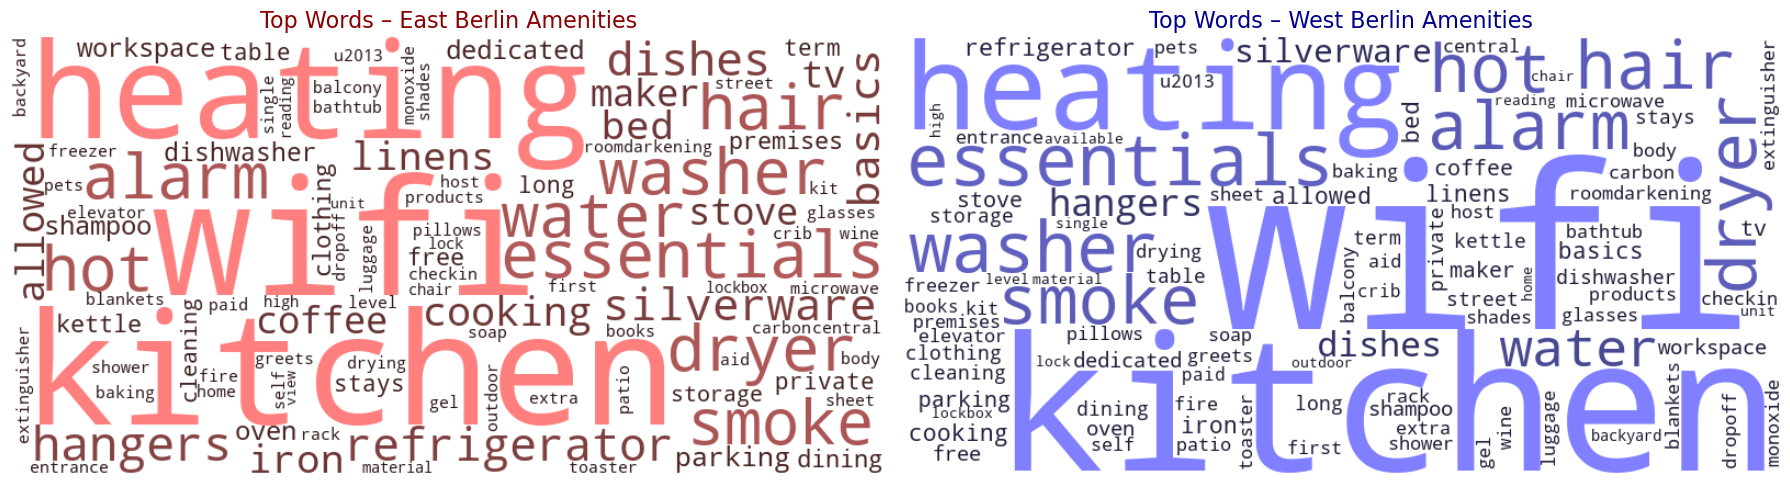

In [34]:
# Step 1: Convert word frequencies to dictionaries
east_freq_dict = east_counts[0].to_dict()
west_freq_dict = west_counts[0].to_dict()

# Step 2: Custom color functions
def red_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    # Bigger = darker red
    red = min(255, font_size * 3)
    return f"rgb({red}, {int(red*0.5)}, {int(red*0.5)})"

def blue_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    # Bigger = darker blue
    blue = min(255, font_size * 3)
    return f"rgb({int(blue*0.5)}, {int(blue*0.5)}, {blue})"

# Step 3: Generate word clouds
wc_east = WordCloud(width=800, height=400, background_color='white',
                    color_func=red_color_func,max_words=100).generate_from_frequencies(east_freq_dict)

wc_west = WordCloud(width=800, height=400, background_color='white',
                    color_func=blue_color_func,max_words=100).generate_from_frequencies(west_freq_dict)

# Step 4: Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

ax1.imshow(wc_east, interpolation='bilinear')
ax1.set_title("Top Words – East Berlin Amenities", fontsize=16, color='darkred')
ax1.axis('off')

ax2.imshow(wc_west, interpolation='bilinear')
ax2.set_title("Top Words – West Berlin Amenities", fontsize=16, color='darkblue')
ax2.axis('off')

plt.tight_layout()
plt.show()

# Save the combined figure
fig.savefig("berlin_wordclouds_east_vs_west_amenities.png", dpi=300, bbox_inches='tight') 

In [35]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# Download VADER if not already
nltk.download('vader_lexicon')

# Step 1: Initialize the analyzer
sia = SentimentIntensityAnalyzer()

# Step 2: Compute sentiment score for each review
df['sentiment_a'] = df['amenities_clean_str'].apply(lambda x: sia.polarity_scores(x)['compound'])

# Step 3: Filter by region
east_amm = df[df['region'] == 'East Berlin']
west_amm = df[df['region'] == 'West Berlin']

east_amm = east_amm.drop_duplicates(subset='amenities')
west_amm = west_amm.drop_duplicates(subset='amenities')

most_positive_east = east_amm.sort_values(by='sentiment_a', ascending=False).head(5)
most_negative_east = east_amm.sort_values(by='sentiment_a').head(5)

most_positive_west = west_amm.sort_values(by='sentiment_a', ascending=False).head(5)
most_negative_west = west_amm.sort_values(by='sentiment_a').head(5)

# Step 5: Display Results
def print_top_amm(df_subset, title):
    print(f"\n{title}")
    print("-" * 60)
    for i, row in df_subset.iterrows():
        print(f"Amenities: {row['amenities']}")
        print(f"Sentiment Score: {row['sentiment_a']}")
        print("-" * 60)

# East
print_top_amm(most_positive_east, "Top 5 Positive Ammenities – East")
print_top_amm(most_negative_east, "Top 5 Negative Ammenities – East")

# West
print_top_amm(most_positive_west, "Top 5 Positive Ammenities – West")
print_top_amm(most_negative_west, "Top 5 Negative Ammenities – West")


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\mc127\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!



Top 5 Positive Ammenities – East
------------------------------------------------------------
Amenities: ["Room-darkening shades", "Cleaning available during stay", "60 inch HDTV with Apple TV", "Hot water kettle", "Long term stays allowed", "Microwave", "Hot water", "Exercise equipment: yoga mat", "Portable fans", "Barbecue utensils", "Smart lock", "Books and reading material", "Hangers", "Body soap", "Pets allowed", "Pool table", "Self check-in", "Cleaning products", "Board games", "Private BBQ grill: gas", "Kitchen", "Standalone high chair - available upon request", "Dishes and silverware", "Outdoor playground", "Miele electric stove", "Safe", "Laundromat nearby", "Freezer", "Shared backyard \u2013 Fully fenced", "Fire extinguisher", "Baby monitor", "Essentials", "Carbon monoxide alarm", "Courtyard view", "Paid street parking off premises", "Single level home", "Wine glasses", "Shampoo", "Extra pillows and blankets", "Ethernet connection", "Marshal sound system with Bluetooth and a

In [36]:
# Select relevant columns for the summary table
cols_to_show = ['amenities', 'sentiment_a', 'review_scores_rating','price']

# Round sentiment scores for readability
most_positive_east['sentiment_a'] = most_positive_east['sentiment_a']
most_negative_east['sentiment_a'] = most_negative_east['sentiment_a']
most_positive_west['sentiment_a'] = most_positive_west['sentiment_a']
most_negative_west['sentiment_a'] = most_negative_west['sentiment_a']

# Display tables
print("Top 5 Positive – East Berlin")
display(most_positive_east[cols_to_show].reset_index(drop=True))

print("Top 5 Negative  – East Berlin")
display(most_negative_east[cols_to_show].reset_index(drop=True))

print("Top 5 Positive  – West Berlin")
display(most_positive_west[cols_to_show].reset_index(drop=True))

print("Top 5 Negative  – West Berlin")
display(most_negative_west[cols_to_show].reset_index(drop=True))


Top 5 Positive – East Berlin


,amenities,sentiment_a,review_scores_rating,price
0,"[""Room-darkening shades"", ""Cleaning available ...",0.9118,NaN,$135.00
1,"[""Wine glasses"", ""Free parking on premises"", ""...",0.9062,NaN,NaN
2,"[""Wine glasses"", ""Bikes"", ""Coffee"", ""Kitchen"",...",0.9042,NaN,$313.00
3,"[""Wine glasses"", ""Bikes"", ""Coffee"", ""Fast wifi...",0.9042,5.00,$657.00
4,"[""Ceiling fan"", ""Safe"", ""Exterior security cam...",0.8957,4.75,$99.00


Top 5 Negative  – East Berlin


,amenities,sentiment_a,review_scores_rating,price
0,"[""Wine glasses"", ""Kitchen"", ""Room-darkening sh...",-0.7184,4.91,$275.00
1,"[""Wine glasses"", ""Coffee"", ""Kitchen"", ""Room-da...",-0.7003,4.87,NaN
2,"[""Fire extinguisher"", ""Hair dryer"", ""Kitchen"",...",-0.5859,5.00,NaN
3,"[""Wine glasses"", ""Kitchen"", ""Shampoo"", ""Bed li...",-0.5859,4.75,$120.00
4,"[""Wine glasses"", ""Coffee"", ""Kitchen"", ""Room-da...",-0.5859,4.79,$115.00


Top 5 Positive  – West Berlin


,amenities,sentiment_a,review_scores_rating,price
0,"[""Wine glasses"", ""Free parking on premises"", ""...",0.9231,4.88,NaN
1,"[""Wine glasses"", ""Coffee"", ""Kitchen"", ""Fair Co...",0.9169,5.00,$353.00
2,"[""Wine glasses"", ""Coffee"", ""Kitchen"", ""Fair Co...",0.9169,4.88,$345.00
3,"[""Wine glasses"", ""Coffee"", ""Kitchen"", ""Fair Co...",0.9169,5.00,$382.00
4,"[""Wine glasses"", ""Coffee"", ""Kitchen"", ""Fair Co...",0.9169,4.93,$337.00


Top 5 Negative  – West Berlin


,amenities,sentiment_a,review_scores_rating,price
0,"[""Wine glasses"", ""Coffee"", ""Kitchen"", ""Shampoo...",-0.8360,4.76,$45.00
1,"[""Fire extinguisher"", ""Kitchen"", ""Smoke alarm""...",-0.5859,NaN,$158.00
2,"[""Coffee maker"", ""Fire extinguisher"", ""Hair dr...",-0.5859,4.94,$90.00
3,"[""Wine glasses"", ""Coffee"", ""Kitchen"", ""Shampoo...",-0.5859,4.96,$55.00
4,"[""Coffee maker"", ""Long term stays allowed"", ""F...",-0.5859,4.76,$84.00


In [37]:
from shapely import wkt

df['geometry'] = df['geometry'].apply(wkt.loads)

import geopandas as gpd
from shapely.geometry import Point


df_gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')  

print(type(df_gdf))
print(df_gdf.geometry.head())
# this file is now ready to be plot
# still need other base layers as map of berlin
print(type(df_gdf))
print(df_gdf.geometry.head())
# this file is now ready to be plot
# still need other base layers as map of berlin

dividing_line = geopandas.read_file(data_dir+"/dividing_line.json")
east_berlin = geopandas.read_file(data_dir+"/east_berlin.json")
west_berlin = geopandas.read_file(data_dir+"/west_berlin.json")

<class 'geopandas.geodataframe.GeoDataFrame'>
0     POINT (13.4181 52.53471)
1    POINT (13.41805 52.53269)
2    POINT (13.40366 52.54813)
3    POINT (13.43508 52.50312)
4    POINT (13.42166 52.49419)
Name: geometry, dtype: geometry
<class 'geopandas.geodataframe.GeoDataFrame'>
0     POINT (13.4181 52.53471)
1    POINT (13.41805 52.53269)
2    POINT (13.40366 52.54813)
3    POINT (13.43508 52.50312)
4    POINT (13.42166 52.49419)
Name: geometry, dtype: geometry


In [38]:
df_gdf.head()

,id,geometry,region,distance_to_wall_m,name,description,neighborhood_overview,amenities,price,review_scores_rating,amenities_lower,amenities_clean,amenities_clean_str,sentiment_a
0,3176,POINT (13.4181 52.53471),East Berlin,1161.272256,Fabulous Flat in great Location,This beautiful first floor apartment is situa...,The neighbourhood is famous for its variety of...,"[""Private hot tub"", ""Wine glasses"", ""Coffee"", ...",$95.00,4.63,"[""private hot tub"", ""wine glasses"", ""coffee"", ...","[cooking, carbon, dinnerware, silverware, long...",cooking carbon dinnerware silverware long shee...,-0.4939
1,9991,POINT (13.41805 52.53269),East Berlin,1291.171194,Geourgeous flat - outstanding views,4 bedroom with very large windows and outstand...,Prenzlauer Berg is an amazing neighbourhood wh...,"[""Kitchen"", ""Room-darkening shades"", ""Bed line...",$180.00,5.00,"[""kitchen"", ""room-darkening shades"", ""bed line...","[silverware, dinnerware, cooking, dropoff, bat...",silverware dinnerware cooking dropoff bathtub ...,-0.3400
2,14325,POINT (13.40366 52.54813),East Berlin,260.201295,Studio Apartment in Prenzlauer Berg,The apartment is located on the upper second f...,NaN,"[""Coffee maker"", ""Kitchen"", ""Hangers"", ""Smoke ...",$75.00,4.68,"[""coffee maker"", ""kitchen"", ""hangers"", ""smoke ...","[silverware, smoke, washer, wifi, kitchen, mak...",silverware smoke washer wifi kitchen maker tv ...,-0.2023
3,16644,POINT (13.43508 52.50312),West Berlin,357.694043,In the Heart of Berlin - Kreuzberg,Light and sunny 2-Room-turn of the century-fla...,Our Part of Kreuzberg is just the best. Good v...,"[""Hair dryer"", ""Kitchen"", ""Room-darkening shad...",$90.00,4.72,"[""hair dryer"", ""kitchen"", ""room-darkening shad...","[carbon, crib, u2019n, kit, hair, childrenu201...",carbon crib u2019n kit hair childrenu2019s smo...,-0.3400
4,17904,POINT (13.42166 52.49419),West Berlin,1142.908319,Beautiful Kreuzberg studio - 3 months minimum,"- apt is available starting September 1, 2024<...","The apartment is located in Kreuzberg, which i...","[""Kitchen"", ""Shampoo"", ""Dishes and silverware""...",$28.00,4.77,"[""kitchen"", ""shampoo"", ""dishes and silverware""...","[silverware, cooking, dropoff, long, basics, s...",silverware cooking dropoff long basics staff h...,0.5106


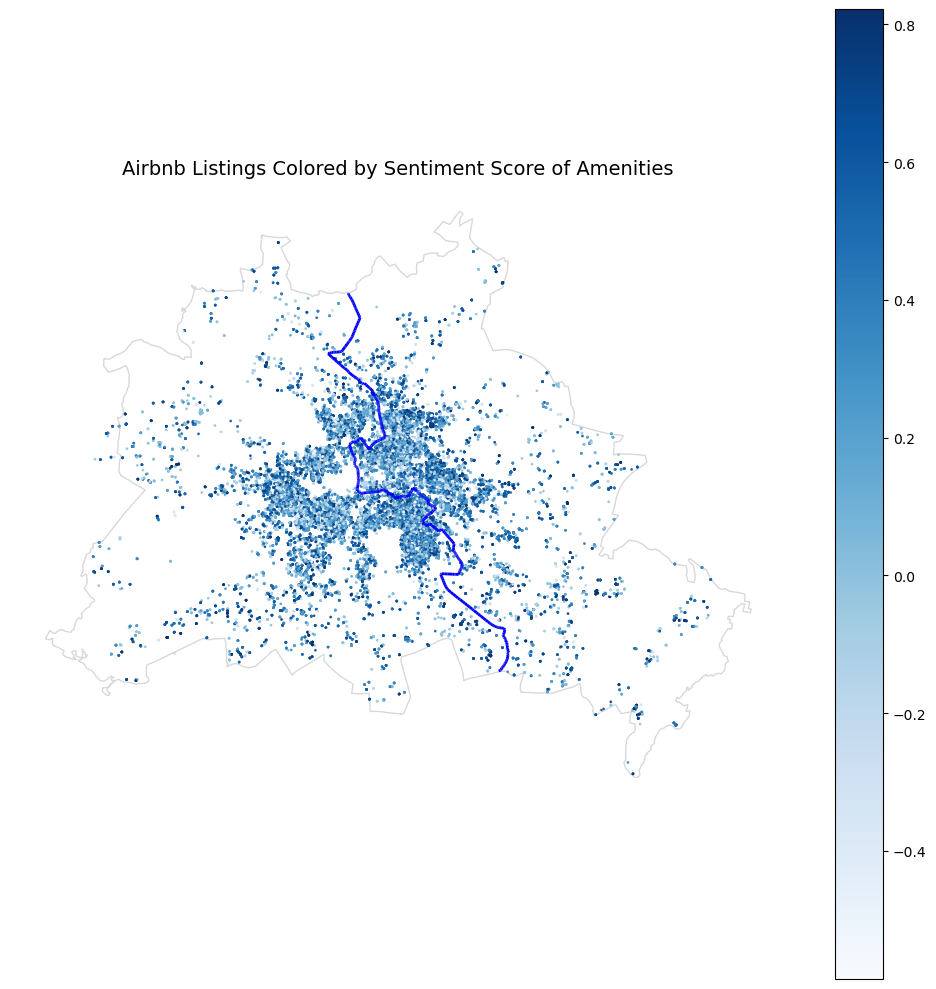

In [39]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

east_berlin.plot(ax=ax, facecolor='white', edgecolor='grey', alpha=0.3)
west_berlin.plot(ax=ax, facecolor='white', edgecolor='grey', alpha=0.3)
dividing_line.plot(ax=ax, color='blue', linewidth=2)

# Normalize sentiment if needed
vmin = df_gdf['sentiment_a'].quantile(0.02)
vmax = df_gdf['sentiment_a'].quantile(0.98)

# Plot sentiment scores
df_gdf.plot(
    ax=ax,
    column='sentiment_a',
    cmap='Blues',       
    markersize=1,
    legend=True,
    alpha=0.8,
    vmin=vmin,
    vmax=vmax
)

ax.set_title("Airbnb Listings Colored by Sentiment Score of Amenities", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.savefig("airbnb_sentiment_map_amenities.png", dpi=300, bbox_inches='tight')
plt.show()

In [40]:
# Clean price column
df['price_clean'] = df['price'].replace('[\$,]', '', regex=True).astype(float)

# Now create a DataFrame with just the relevant columns
price_and_amm = df[['sentiment_a', 'price_clean']]

# Compute correlation matrix
correlation_matrix = price_and_amm.corr()
print(correlation_matrix) 

             sentiment_a  price_clean
sentiment_a     1.000000     0.024721
price_clean     0.024721     1.000000


<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
C:\Users\mc127\AppData\Local\Temp\ipykernel_55332\3079222916.py:2: SyntaxWarning: invalid escape sequence '\$'
  df['price_clean'] = df['price'].replace('[\$,]', '', regex=True).astype(float)


### Sentiment Analysis of Neighbourhood Overview

In [41]:
df = pd.read_csv(data_dir+"merged_airbnb.csv")
import string
string.punctuation

# This maketrans function can be used to remove a list of characters from a string.
remv_punc = str.maketrans('','',string.punctuation + '“' +"‘"+'”')
# Make the text lowercase, then replace "\n" with white space " "

df['no_lower'] =  df['neighborhood_overview'].str.lower().str.replace("\n"," ")
df['no_clean'] = df.no_lower.str.translate(remv_punc)
df['no_clean'] = df['no_clean'].fillna('')


In [42]:
from nltk.corpus import stopwords
# Download the stopwords, but add another list with "amp", "", and white space " "
eng_stop = stopwords.words('english')
ger_stop = stopwords.words('german')
custom_stop = ['amp', '', ' ']  # add more if needed
all_stopwords = eng_stop + ger_stop + custom_stop

# For each tweet text, split on the whitespace to get a list of words
df['no_clean'] = [x.split(" ") for x in df['no_clean']]


# Convert the text to a set, subtract the set of stopwords, turn into list
df['no_clean'] = [list(set(x) - set(all_stopwords )) for x in df['no_clean']]


In [43]:
from sklearn.feature_extraction.text import CountVectorizer
df['no_clean_str'] = df['no_clean'].apply(lambda x: ' '.join(x))

vct = CountVectorizer(stop_words=all_stopwords )
X = vct.fit_transform(list(df['no_clean_str']))
X
word_counts = pd.DataFrame(X.sum(axis=0))
word_counts.columns = vct.get_feature_names_out()
word_counts = word_counts.T
word_counts[0].sort_values(ascending=False).head(20)

restaurants     12615
berlin          12164
bars             8368
located          7474
br               7171
cafes            6690
area             6552
apartment        6406
minutes          6202
shops            6077
neighborhood     5886
walk             5835
away             5362
walking          5321
many             5203
within           5012
around           4773
city             4636
quiet            4610
shopping         4600
Name: 0, dtype: int64

In [44]:
# Subset data
east_df = df[df['region'] == 'East Berlin']
west_df = df[df['region'] == 'West Berlin']

# CountVectorizer for East
X_east = vct.fit_transform(list(east_df['no_clean_str']))
east_counts = pd.DataFrame(X_east.sum(axis=0))
east_counts.columns = vct.get_feature_names_out()
east_counts = east_counts.T
print("Top 10 East words:")
print(east_counts[0].sort_values(ascending=False).head(10))

# CountVectorizer for West
X_west = vct.fit_transform(list(west_df['no_clean_str']))
west_counts = pd.DataFrame(X_west.sum(axis=0))
west_counts.columns = vct.get_feature_names_out()
west_counts = west_counts.T
print("\nTop 10 West words:")
print(west_counts[0].sort_values(ascending=False).head(10))


Top 10 East words:
restaurants    6125
berlin         5884
bars           4080
located        3662
br             3657
cafes          3110
area           3078
apartment      3069
minutes        3065
shops          2937
Name: 0, dtype: int64

Top 10 West words:
restaurants     6486
berlin          6276
bars            4288
located         3808
cafes           3580
br              3514
area            3462
apartment       3333
neighborhood    3223
shops           3140
Name: 0, dtype: int64


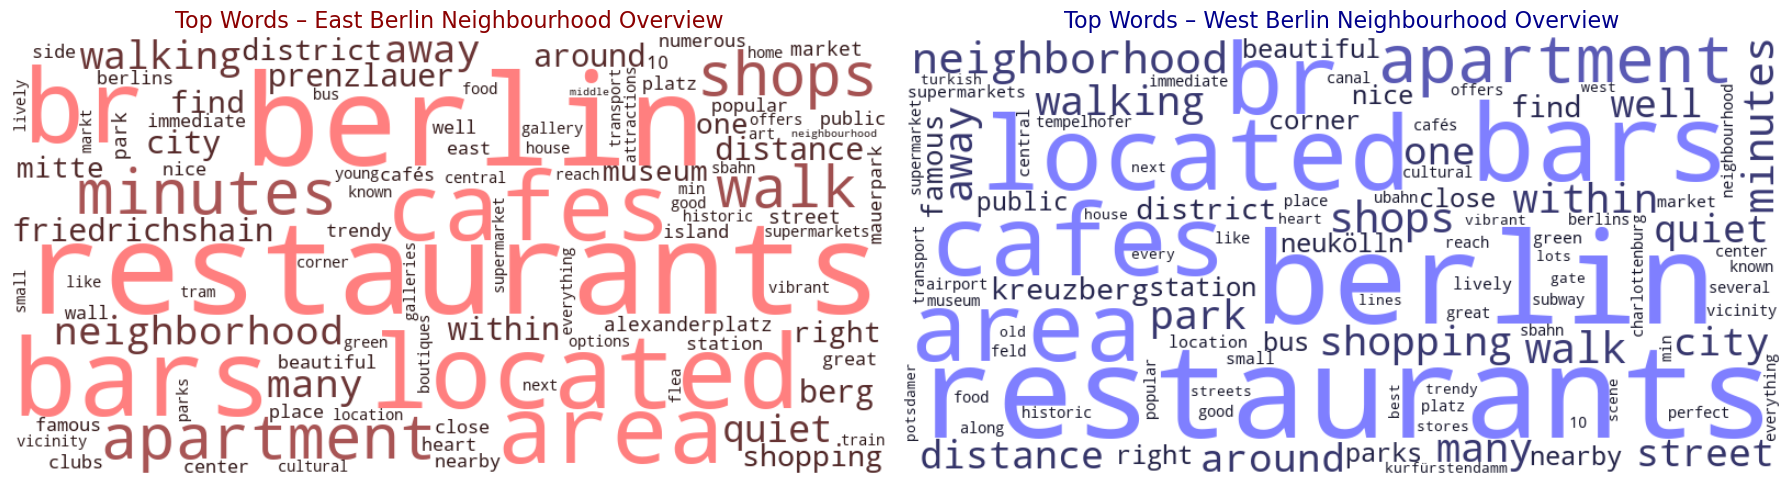

In [45]:
# Step 1: Convert word frequencies to dictionaries
east_freq_dict = east_counts[0].to_dict()
west_freq_dict = west_counts[0].to_dict()

# Step 2: Custom color functions
def red_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    # Bigger = darker red
    red = min(255, font_size * 3)
    return f"rgb({red}, {int(red*0.5)}, {int(red*0.5)})"

def blue_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    # Bigger = darker blue
    blue = min(255, font_size * 3)
    return f"rgb({int(blue*0.5)}, {int(blue*0.5)}, {blue})"

# Step 3: Generate word clouds
wc_east = WordCloud(width=800, height=400, background_color='white',
                    color_func=red_color_func,max_words=100).generate_from_frequencies(east_freq_dict)

wc_west = WordCloud(width=800, height=400, background_color='white',
                    color_func=blue_color_func,max_words=100).generate_from_frequencies(west_freq_dict)

# Step 4: Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

ax1.imshow(wc_east, interpolation='bilinear')
ax1.set_title("Top Words – East Berlin Neighbourhood Overview", fontsize=16, color='darkred')
ax1.axis('off')

ax2.imshow(wc_west, interpolation='bilinear')
ax2.set_title("Top Words – West Berlin Neighbourhood Overview", fontsize=16, color='darkblue')
ax2.axis('off')

plt.tight_layout()
plt.show()
# Save the combined figure
fig.savefig("berlin_wordclouds_east_vs_west_neghbourhood_overview.png", dpi=300, bbox_inches='tight')


In [46]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# Download VADER if not already
nltk.download('vader_lexicon')

# Step 1: Initialize the analyzer
sia = SentimentIntensityAnalyzer()

# Step 2: Compute sentiment score for each review
df['sentiment_n'] = df['no_clean_str'].apply(lambda x: sia.polarity_scores(x)['compound'])

# Step 3: Filter by region
east_no = df[df['region'] == 'East Berlin']
west_no = df[df['region'] == 'West Berlin']

east_no = east_no.drop_duplicates(subset='neighborhood_overview')
west_no = west_no.drop_duplicates(subset='neighborhood_overview')

most_positive_east = east_no.sort_values(by='sentiment_n', ascending=False).head(5)
most_negative_east = east_no.sort_values(by='sentiment_n').head(5)

most_positive_west = west_no.sort_values(by='sentiment_n', ascending=False).head(5)
most_negative_west = west_no.sort_values(by='sentiment_n').head(5)

# Step 5: Display Results
def print_top_no(df_subset, title):
    print(f"\n{title}")
    print("-" * 60)
    for i, row in df_subset.iterrows():
        print(f"Neighbourhood Overview: {row['neighborhood_overview']}")
        print(f"Sentiment Score: {row['sentiment_n']}")
        print("-" * 60)

# East
print_top_no(most_positive_east, "Top 5 Positive Neighbourhood – East")
print_top_no(most_negative_east, "Top 5 Negative Neighbourhood – East")

# West
print_top_no(most_positive_west, "Top 5 Positive Neighbourhood – West")
print_top_no(most_negative_west, "Top 5 Negative Neighbourhood – West")


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\mc127\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!



Top 5 Positive Neighbourhood – East
------------------------------------------------------------
Neighbourhood Overview: Friedrichshain, nestled in the vibrant heart of Berlin, is a district that exudes an irresistible charm. It captivates visitors with its dynamic ambience, thriving nightlife, and rich cultural offerings. Whether you're seeking creative inspiration or culinary delights, Friedrichshain's abundance of cafes, bars, and restaurants will satisfy your every desire. Within this spirited district, the Boxhagener Kiez stands out as a beloved neighbourhood. Its vibrant energy permeates the air, inviting you to explore its eclectic mix of attractions. Experience the joy of strolling through the renowned Boxhagener Platz flea market, where hidden gems and delectable street food await. Delight in the cosy cafés, trendy bars, and diverse dining options that define this thriving district.
Sentiment Score: 0.9944
------------------------------------------------------------
Neighbour

In [47]:
# Select relevant columns for the summary table
cols_to_show = ['neighborhood_overview', 'sentiment_n', 'review_scores_rating','price']

# Round sentiment scores for readability
most_positive_east['sentiment_n'] = most_positive_east['sentiment_n']
most_negative_east['sentiment_n'] = most_negative_east['sentiment_n']
most_positive_west['sentiment_n'] = most_positive_west['sentiment_n']
most_negative_west['sentiment_n'] = most_negative_west['sentiment_n']

# Display tables
print("Top 5 Positive – East Berlin")
display(most_positive_east[cols_to_show].reset_index(drop=True))

print("Top 5 Negative  – East Berlin")
display(most_negative_east[cols_to_show].reset_index(drop=True))

print("Top 5 Positive  – West Berlin")
display(most_positive_west[cols_to_show].reset_index(drop=True))

print("Top 5 Negative  – West Berlin")
display(most_negative_west[cols_to_show].reset_index(drop=True))


Top 5 Positive – East Berlin


,neighborhood_overview,sentiment_n,review_scores_rating,price
0,"Friedrichshain, nestled in the vibrant heart o...",0.9944,NaN,$80.00
1,"Our apartment enjoys a prime location, just a ...",0.9940,4.95,$65.00
2,The district of Prenzlauer Berg in Berlin is c...,0.9926,4.83,$197.00
3,"Experience the charm of Prenzlauer Berg, Berli...",0.9915,4.89,$359.00
4,This vibrant and historically rich neighborhoo...,0.9911,4.94,$163.00


Top 5 Negative  – East Berlin


,neighborhood_overview,sentiment_n,review_scores_rating,price
0,Prenzlauer Berg is characterised by old buildi...,-0.8720,4.68,$68.00
1,The neighbourhood is strange even though this ...,-0.6808,4.89,NaN
2,The neighborhood is very quiet and my neighbor...,-0.6571,5.00,NaN
3,"No noisy, disturbing neighbors.",-0.6124,NaN,NaN
4,"We have many small coffees around the corner, ...",-0.6124,NaN,NaN


Top 5 Positive  – West Berlin


,neighborhood_overview,sentiment_n,review_scores_rating,price
0,Steglitz is a charming and vibrant neighborhoo...,0.9925,NaN,$159.00
1,Numa Berlin Kudamm is located in the Charlotte...,0.9911,4.54,$67.00
2,The location is simply unbeatable! You will fi...,0.9907,5.00,NaN
3,Our guest room is conveniently located in a vi...,0.9898,4.87,$35.00
4,"Welcome to Schöneberg, a neighborhood where th...",0.9897,4.85,$85.00


Top 5 Negative  – West Berlin


,neighborhood_overview,sentiment_n,review_scores_rating,price
0,"We are right in the heart of Berlin, the distr...",-0.7137,4.70,$215.00
1,"There are many sights within walking distance,...",-0.5994,5.00,NaN
2,You will stay in the heart of multicultural Kr...,-0.5574,NaN,NaN
3,The Berliner Hansaviertel was redesigned after...,-0.5325,4.85,$89.00
4,You will live in the middle of one of Kreuzber...,-0.5267,4.87,NaN


In [48]:
from shapely import wkt

df['geometry'] = df['geometry'].apply(wkt.loads)

import geopandas as gpd
from shapely.geometry import Point


df_gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')  

print(type(df_gdf))
print(df_gdf.geometry.head())
# this file is now ready to be plot
# still need other base layers as map of berlin
print(type(df_gdf))
print(df_gdf.geometry.head())
# this file is now ready to be plot
# still need other base layers as map of berlin

dividing_line = geopandas.read_file(data_dir+"/dividing_line.json")
east_berlin = geopandas.read_file(data_dir+"/east_berlin.json")
west_berlin = geopandas.read_file(data_dir+"/west_berlin.json")

<class 'geopandas.geodataframe.GeoDataFrame'>
0     POINT (13.4181 52.53471)
1    POINT (13.41805 52.53269)
2    POINT (13.40366 52.54813)
3    POINT (13.43508 52.50312)
4    POINT (13.42166 52.49419)
Name: geometry, dtype: geometry
<class 'geopandas.geodataframe.GeoDataFrame'>
0     POINT (13.4181 52.53471)
1    POINT (13.41805 52.53269)
2    POINT (13.40366 52.54813)
3    POINT (13.43508 52.50312)
4    POINT (13.42166 52.49419)
Name: geometry, dtype: geometry


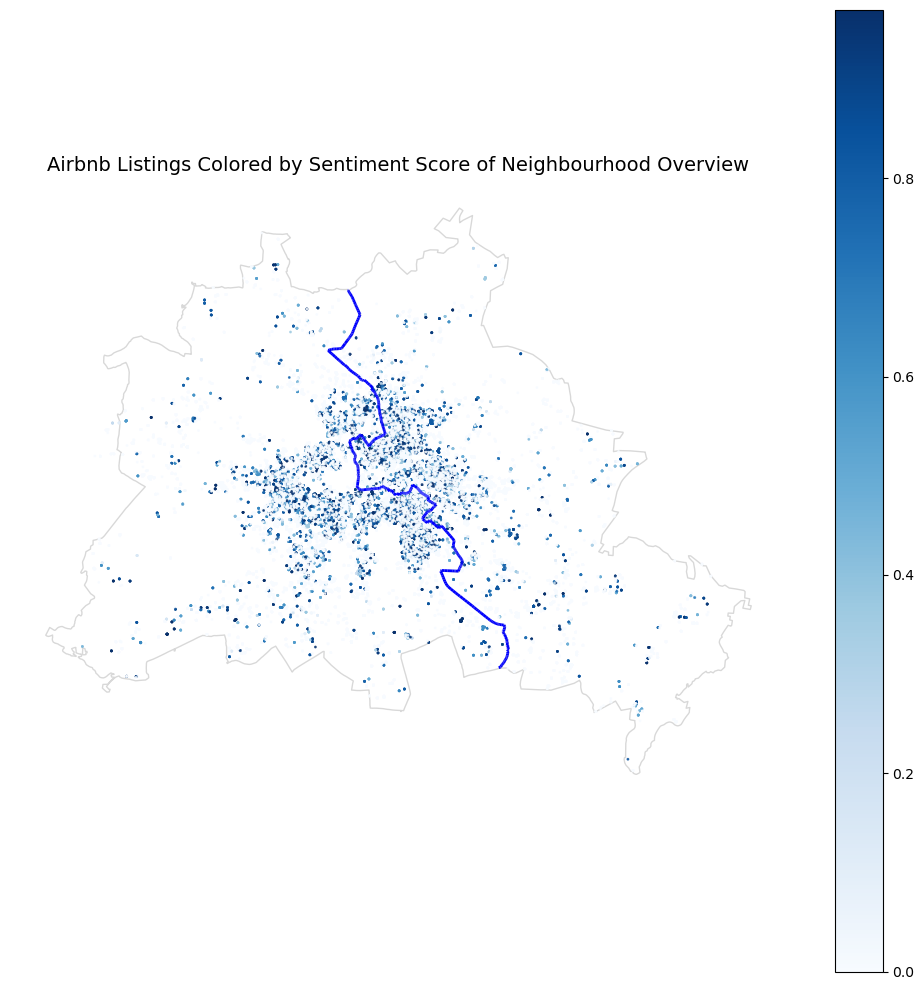

In [49]:
fig, ax = plt.subplots(figsize=(10, 10))

east_berlin.plot(ax=ax, facecolor='white', edgecolor='grey', alpha=0.3)
west_berlin.plot(ax=ax, facecolor='white', edgecolor='grey', alpha=0.3)
dividing_line.plot(ax=ax, color='blue', linewidth=2)

# Normalize sentiment if needed
vmin = df_gdf['sentiment_n'].quantile(0.02)
vmax = df_gdf['sentiment_n'].quantile(0.98)

# Plot sentiment scores
df_gdf.plot(
    ax=ax,
    column='sentiment_n',
    cmap='Blues',       
    markersize=1,
    legend=True,
    alpha=0.8,
    vmin=vmin,
    vmax=vmax
)

ax.set_title("Airbnb Listings Colored by Sentiment Score of Neighbourhood Overview", fontsize=14)
ax.axis("off")
plt.tight_layout()

plt.savefig("airbnb_sentiment_map_neighbourhood_overview.png", dpi=300, bbox_inches='tight')
plt.show()

In [50]:
# Clean price column
df['price_clean'] = df['price'].replace('[\$,]', '', regex=True).astype(float)

# Now create a DataFrame with just the relevant columns
price_and_amm = df[['sentiment_n', 'price_clean']]

# Compute correlation matrix
correlation_matrix = price_and_amm.corr()
print(correlation_matrix)

             sentiment_n  price_clean
sentiment_n     1.000000     0.003225
price_clean     0.003225     1.000000


<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
C:\Users\mc127\AppData\Local\Temp\ipykernel_55332\1205836227.py:2: SyntaxWarning: invalid escape sequence '\$'
  df['price_clean'] = df['price'].replace('[\$,]', '', regex=True).astype(float)


### Sentiment Analysis of Description

In [51]:
df = pd.read_csv(data_dir+"merged_airbnb.csv")
import string
string.punctuation

# This maketrans function can be used to remove a list of characters from a string.
remv_punc = str.maketrans('','',string.punctuation + '“' +"‘"+'”')
# Make the text lowercase, then replace "\n" with white space " "

df['des_lower'] =  df['description'].str.lower().str.replace("\n"," ")
df['des_clean'] = df.des_lower.str.translate(remv_punc)
df['des_clean'] = df['des_clean'].fillna('')

In [52]:
from nltk.corpus import stopwords
# Download the stopwords, but add another list with "amp", "", and white space " "
eng_stop = stopwords.words('english')
ger_stop = stopwords.words('german')
custom_stop = ['amp', '', ' ']  # add more if needed
all_stopwords = eng_stop + ger_stop + custom_stop

# For each tweet text, split on the whitespace to get a list of words
df['des_clean'] = [x.split(" ") for x in df['des_clean']]


# Convert the text to a set, subtract the set of stopwords, turn into list
df['des_clean'] = [list(set(x) - set(all_stopwords )) for x in df['des_clean']]


In [53]:
from sklearn.feature_extraction.text import CountVectorizer
df['des_clean_str'] = df['des_clean'].apply(lambda x: ' '.join(x))

vct = CountVectorizer(stop_words=all_stopwords )
X = vct.fit_transform(list(df['des_clean_str']))
X
word_counts = pd.DataFrame(X.sum(axis=0))
word_counts.columns = vct.get_feature_names_out()
word_counts = word_counts.T
word_counts[0].sort_values(ascending=False).head(20)

apartment      26835
berlin         20168
br             18056
room           17984
located        15751
kitchen        14283
quiet          10720
living          9732
bathroom        9496
restaurants     9269
bed             9110
beautiful       8291
equipped        7948
city            7357
minutes         7219
area            7111
fully           7016
balcony         6937
floor           6692
heart           6603
Name: 0, dtype: int64

In [54]:
# Subset data
east_df = df[df['region'] == 'East Berlin']
west_df = df[df['region'] == 'West Berlin']

# CountVectorizer for East
X_east = vct.fit_transform(list(east_df['des_clean_str']))
east_counts = pd.DataFrame(X_east.sum(axis=0))
east_counts.columns = vct.get_feature_names_out()
east_counts = east_counts.T
print("Top 10 East words:")
print(east_counts[0].sort_values(ascending=False).head(10))

# CountVectorizer for West
X_west = vct.fit_transform(list(west_df['des_clean_str']))
west_counts = pd.DataFrame(X_west.sum(axis=0))
west_counts.columns = vct.get_feature_names_out()
west_counts = west_counts.T
print("\nTop 10 West words:")
print(west_counts[0].sort_values(ascending=False).head(10))


Top 10 East words:
apartment      12355
berlin          9648
br              8448
room            7777
located         7641
kitchen         6551
quiet           4996
living          4600
restaurants     4424
bathroom        4369
Name: 0, dtype: int64

Top 10 West words:
apartment    14472
berlin       10517
room         10199
br            9595
located       8107
kitchen       7724
quiet         5717
living        5132
bathroom      5123
bed           4936
Name: 0, dtype: int64


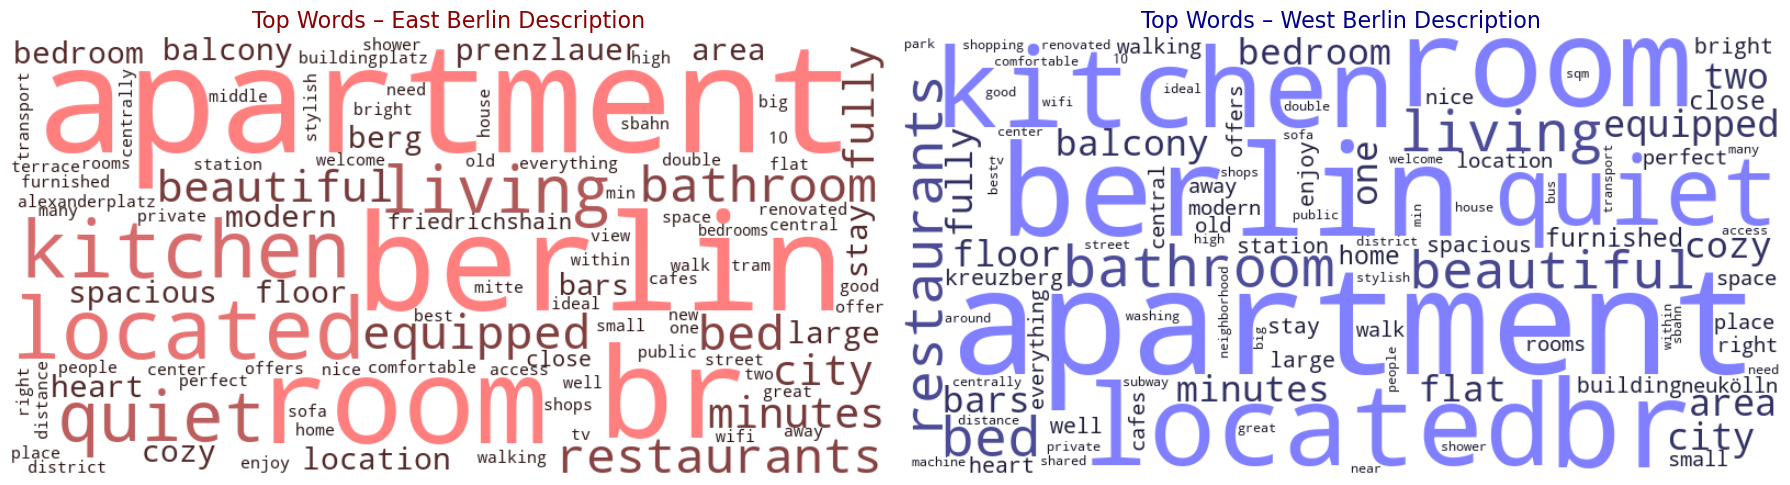

In [55]:
# Step 1: Convert word frequencies to dictionaries
east_freq_dict = east_counts[0].to_dict()
west_freq_dict = west_counts[0].to_dict()

# Step 2: Custom color functions
def red_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    # Bigger = darker red
    red = min(255, font_size * 3)
    return f"rgb({red}, {int(red*0.5)}, {int(red*0.5)})"

def blue_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    # Bigger = darker blue
    blue = min(255, font_size * 3)
    return f"rgb({int(blue*0.5)}, {int(blue*0.5)}, {blue})"

# Step 3: Generate word clouds
wc_east = WordCloud(width=800, height=400, background_color='white',
                    color_func=red_color_func,max_words=100).generate_from_frequencies(east_freq_dict)

wc_west = WordCloud(width=800, height=400, background_color='white',
                    color_func=blue_color_func,max_words=100).generate_from_frequencies(west_freq_dict)

# Step 4: Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

ax1.imshow(wc_east, interpolation='bilinear')
ax1.set_title("Top Words – East Berlin Description", fontsize=16, color='darkred')
ax1.axis('off')

ax2.imshow(wc_west, interpolation='bilinear')
ax2.set_title("Top Words – West Berlin Description", fontsize=16, color='darkblue')
ax2.axis('off')

plt.tight_layout()
plt.show()
# Save the combined figure
fig.savefig("berlin_wordclouds_east_vs_west_description.png", dpi=300, bbox_inches='tight')

In [56]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# Download VADER if not already
nltk.download('vader_lexicon')

# Step 1: Initialize the analyzer
sia = SentimentIntensityAnalyzer()

# Step 2: Compute sentiment score for each review
df['sentiment_d'] = df['des_clean_str'].apply(lambda x: sia.polarity_scores(x)['compound'])

# Step 3: Filter by region
east_des = df[df['region'] == 'East Berlin']
west_des = df[df['region'] == 'West Berlin']

east_des = east_des.drop_duplicates(subset='description')
west_des = west_des.drop_duplicates(subset='description')

most_positive_east = east_des.sort_values(by='sentiment_d', ascending=False).head(5)
most_negative_east = east_des.sort_values(by='sentiment_d').head(5)

most_positive_west = west_des.sort_values(by='sentiment_d', ascending=False).head(5)
most_negative_west = west_des.sort_values(by='sentiment_d').head(5)

# Step 5: Display Results
def print_top_no(df_subset, title):
    print(f"\n{title}")
    print("-" * 60)
    for i, row in df_subset.iterrows():
        print(f"Description: {row['description']}")
        print(f"Sentiment Score: {row['sentiment_d']}")
        print("-" * 60)

# East
print_top_no(most_positive_east, "Top 5 Positive Description – East")
print_top_no(most_negative_east, "Top 5 Negative Description – East")

# West
print_top_no(most_positive_west, "Top 5 Positive Description – West") 
print_top_no(most_negative_west, "Top 5 Negative Description – West")


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\mc127\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!



Top 5 Positive Description – East
------------------------------------------------------------
Description: Welcome to our stunning apartment in a peaceful family-friendly neighborhood, perfect for an amazing vacation. This spacious and well-appointed apartment offers all amenities for a comfortable stay. Relax in the serene living room or enjoy a peaceful sleep in the cozy bedrooms. The fully-equipped kitchen allows for delicious meals, and nearby attractions offer adventure and exploration. Experience an unforgettable holiday in this tranquil retreat.
Sentiment Score: 0.9913
------------------------------------------------------------
Description: This apartment is directly in the vivid center of Berlin. Theater, opera, bars and Restaurants, you´ll find everything that you need just around the corner. Perfectly connected by public transportation (main station is just a short distance) your possibilities are endless! <br />Enjoy the stay, I love my flat, I hope you like it too;) <br 

In [57]:
# Select relevant columns for the summary table
cols_to_show = ['description', 'sentiment_d', 'review_scores_rating','price']

# Round sentiment scores for readability
most_positive_east['sentiment_d'] = most_positive_east['sentiment_d']
most_negative_east['sentiment_d'] = most_negative_east['sentiment_d']
most_positive_west['sentiment_d'] = most_positive_west['sentiment_d']
most_negative_west['sentiment_d'] = most_negative_west['sentiment_d']

# Display tables
print("Top 5 Positive – East Berlin")
display(most_positive_east[cols_to_show].reset_index(drop=True))

print("Top 5 Negative  – East Berlin")
display(most_negative_east[cols_to_show].reset_index(drop=True))

print("Top 5 Positive  – West Berlin")
display(most_positive_west[cols_to_show].reset_index(drop=True))

print("Top 5 Negative  – West Berlin")
display(most_negative_west[cols_to_show].reset_index(drop=True))

Top 5 Positive – East Berlin


,description,sentiment_d,review_scores_rating,price
0,Welcome to our stunning apartment in a peacefu...,0.9913,3.50,$229.00
1,This apartment is directly in the vivid center...,0.9903,4.95,$156.00
2,Indulge in modern comfort and style in the apa...,0.9885,4.85,$121.00
3,Take it easy at this unique and tranquil getaw...,0.9884,NaN,$120.00
4,Welcome to our stylish 3-room flat in Prenzlau...,0.9882,5.00,$150.00


Top 5 Negative  – East Berlin


,description,sentiment_d,review_scores_rating,price
0,Lovely attic maisonette in Berlin Friedrichsha...,-0.7329,4.89,NaN
1,The flat is fully furnished and newly renovate...,-0.6486,4.14,$80.00
2,The apartment is in a beautifully renovated ty...,-0.6254,5.00,NaN
3,I rent out my beautiful Art Studio in Prenzlau...,-0.6182,4.83,$116.00
4,"""Gardenroom"" in a modern townhouse, located in...",-0.5994,4.87,$69.00


Top 5 Positive  – West Berlin


,description,sentiment_d,review_scores_rating,price
0,This beautifully renovated flat in Schöneberg ...,0.9917,NaN,$62.00
1,Welcome to a charming and serene private studi...,0.9911,4.82,$65.00
2,Tucked away in the eclectic district of Kreuzb...,0.9908,NaN,$98.00
3,"Our apartment is situated in a serene, calm an...",0.9903,5.00,$76.00
4,Welcome to my beautifully renovated historic a...,0.9893,5.00,NaN


Top 5 Negative  – West Berlin


,description,sentiment_d,review_scores_rating,price
0,In a quiet side street of Schlossstraße in Ste...,-0.8720,4.94,$71.00
1,Quite apartment in the heart of West Berlin. O...,-0.7003,NaN,NaN
2,We are a family of 4 and home in the wonderful...,-0.5856,4.67,NaN
3,We rent our apartment (except for bedroom) to ...,-0.5773,NaN,NaN
4,"Berlin typical old house, the room is in the i...",-0.5719,NaN,NaN


In [58]:
from shapely import wkt

df['geometry'] = df['geometry'].apply(wkt.loads)

import geopandas as gpd
from shapely.geometry import Point


df_gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')  

print(type(df_gdf))
print(df_gdf.geometry.head())
# this file is now ready to be plot
# still need other base layers as map of berlin
print(type(df_gdf))
print(df_gdf.geometry.head())
# this file is now ready to be plot
# still need other base layers as map of berlin

dividing_line = geopandas.read_file(data_dir+"/dividing_line.json")
east_berlin = geopandas.read_file(data_dir+"/east_berlin.json")
west_berlin = geopandas.read_file(data_dir+"/west_berlin.json")

<class 'geopandas.geodataframe.GeoDataFrame'>
0     POINT (13.4181 52.53471)
1    POINT (13.41805 52.53269)
2    POINT (13.40366 52.54813)
3    POINT (13.43508 52.50312)
4    POINT (13.42166 52.49419)
Name: geometry, dtype: geometry
<class 'geopandas.geodataframe.GeoDataFrame'>
0     POINT (13.4181 52.53471)
1    POINT (13.41805 52.53269)
2    POINT (13.40366 52.54813)
3    POINT (13.43508 52.50312)
4    POINT (13.42166 52.49419)
Name: geometry, dtype: geometry


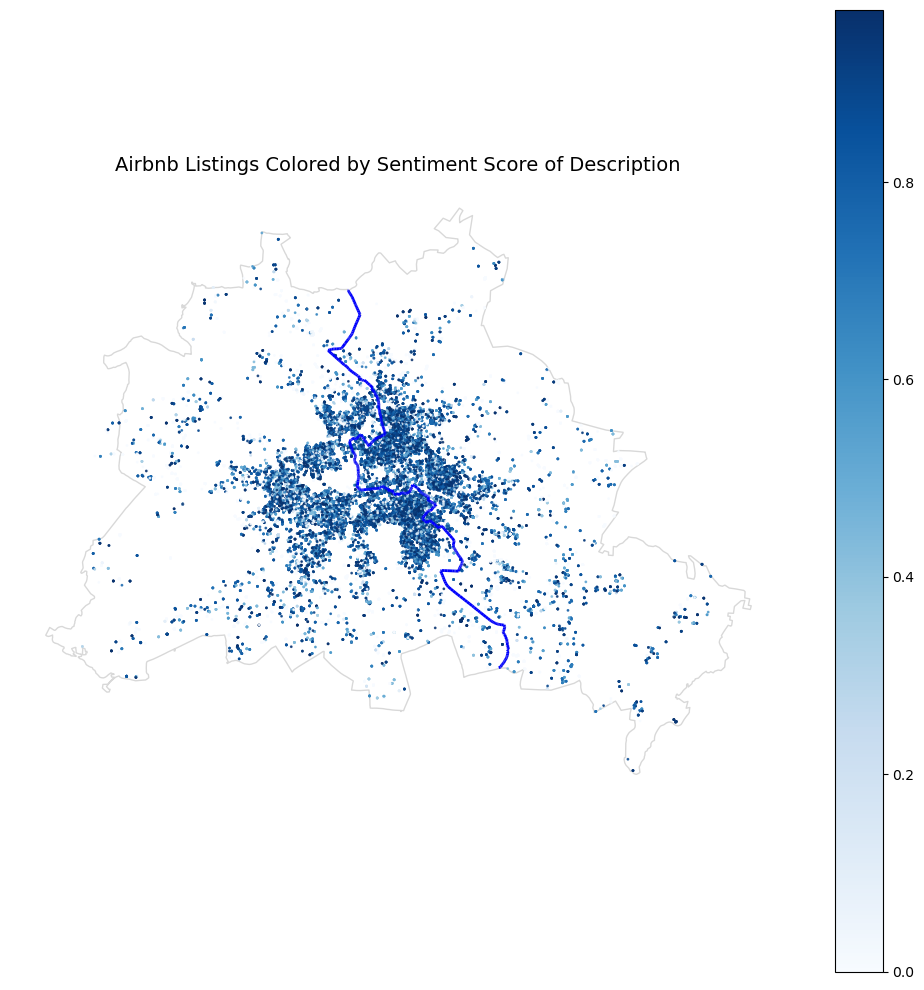

In [59]:
fig, ax = plt.subplots(figsize=(10, 10))

east_berlin.plot(ax=ax, facecolor='white', edgecolor='grey', alpha=0.3)
west_berlin.plot(ax=ax, facecolor='white', edgecolor='grey', alpha=0.3)
dividing_line.plot(ax=ax, color='blue', linewidth=2)

# Normalize sentiment if needed
vmin = df_gdf['sentiment_d'].quantile(0.02)
vmax = df_gdf['sentiment_d'].quantile(0.98)

# Plot sentiment scores
df_gdf.plot(
    ax=ax,
    column='sentiment_d',
    cmap='Blues',       
    markersize=1,
    legend=True,
    alpha=0.8,
    vmin=vmin,
    vmax=vmax
)

ax.set_title("Airbnb Listings Colored by Sentiment Score of Description", fontsize=14)
ax.axis("off")
plt.tight_layout()

plt.savefig("airbnb_sentiment_map_description.png", dpi=300, bbox_inches='tight')
plt.show() 


In [60]:
# Clean price column
df['price_clean'] = df['price'].replace('[\$,]', '', regex=True).astype(float)

# Now create a DataFrame with just the relevant columns
price_and_amm = df[['sentiment_d', 'price_clean']]

# Compute correlation matrix
correlation_matrix = price_and_amm.corr()
print(correlation_matrix)

             sentiment_d  price_clean
sentiment_d     1.000000    -0.016206
price_clean    -0.016206     1.000000


<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
C:\Users\mc127\AppData\Local\Temp\ipykernel_55332\2426780777.py:2: SyntaxWarning: invalid escape sequence '\$'
  df['price_clean'] = df['price'].replace('[\$,]', '', regex=True).astype(float)


### Sentiment Analysis of Name

In [61]:

df = pd.read_csv(data_dir+"merged_airbnb.csv")
import string
string.punctuation

# This maketrans function can be used to remove a list of characters from a string.
remv_punc = str.maketrans('','',string.punctuation + '“' +"‘"+'”')
# Make the text lowercase, then replace "\n" with white space " "

df['na_lower'] =  df['name'].str.lower().str.replace("\n"," ")
df['na_clean'] = df.na_lower.str.translate(remv_punc)
df['na_clean'] = df['na_clean'].fillna('')

In [62]:
from nltk.corpus import stopwords
# Download the stopwords, but add another list with "amp", "", and white space " "
eng_stop = stopwords.words('english')
ger_stop = stopwords.words('german')
custom_stop = ['amp', '', ' ']  # add more if needed
all_stopwords = eng_stop + ger_stop + custom_stop

# For each tweet text, split on the whitespace to get a list of words
df['na_clean'] = [x.split(" ") for x in df['na_clean']]


# Convert the text to a set, subtract the set of stopwords, turn into list
df['na_clean'] = [list(set(x) - set(all_stopwords )) for x in df['na_clean']]


In [63]:
from sklearn.feature_extraction.text import CountVectorizer
df['na_clean_str'] = df['na_clean'].apply(lambda x: ' '.join(x))

vct = CountVectorizer(stop_words=all_stopwords )
X = vct.fit_transform(list(df['na_clean_str']))
X
word_counts = pd.DataFrame(X.sum(axis=0))
word_counts.columns = vct.get_feature_names_out()
word_counts = word_counts.T
word_counts[0].sort_values(ascending=False).head(20)

apartment     10748
berlin         8871
room           8280
flat           3825
cozy           3523
kreuzberg      2798
central        2690
zimmer         2681
studio         2575
mitte          2409
wohnung        2347
neukölln       2151
cosy           2101
bright         2045
berg           1939
heart          1896
beautiful      1890
prenzlauer     1883
spacious       1826
balcony        1778
Name: 0, dtype: int64

In [64]:
# Subset data
east_df = df[df['region'] == 'East Berlin']
west_df = df[df['region'] == 'West Berlin']

# CountVectorizer for East
X_east = vct.fit_transform(list(east_df['na_clean_str']))
east_counts = pd.DataFrame(X_east.sum(axis=0))
east_counts.columns = vct.get_feature_names_out()
east_counts = east_counts.T
print("Top 10 East words:")
print(east_counts[0].sort_values(ascending=False).head(10))

# CountVectorizer for West
X_west = vct.fit_transform(list(west_df['na_clean_str']))
west_counts = pd.DataFrame(X_west.sum(axis=0))
west_counts.columns = vct.get_feature_names_out()
west_counts = west_counts.T
print("\nTop 10 West words:")
print(west_counts[0].sort_values(ascending=False).head(10))

Top 10 East words:
apartment         5166
berlin            4538
room              3367
berg              1923
prenzlauer        1867
mitte             1810
flat              1801
friedrichshain    1698
cozy              1514
central           1346
Name: 0, dtype: int64

Top 10 West words:
apartment    5574
room         4913
berlin       4326
kreuzberg    2751
neukölln     2143
flat         2024
cozy         2009
zimmer       1625
studio       1388
wohnung      1346
Name: 0, dtype: int64


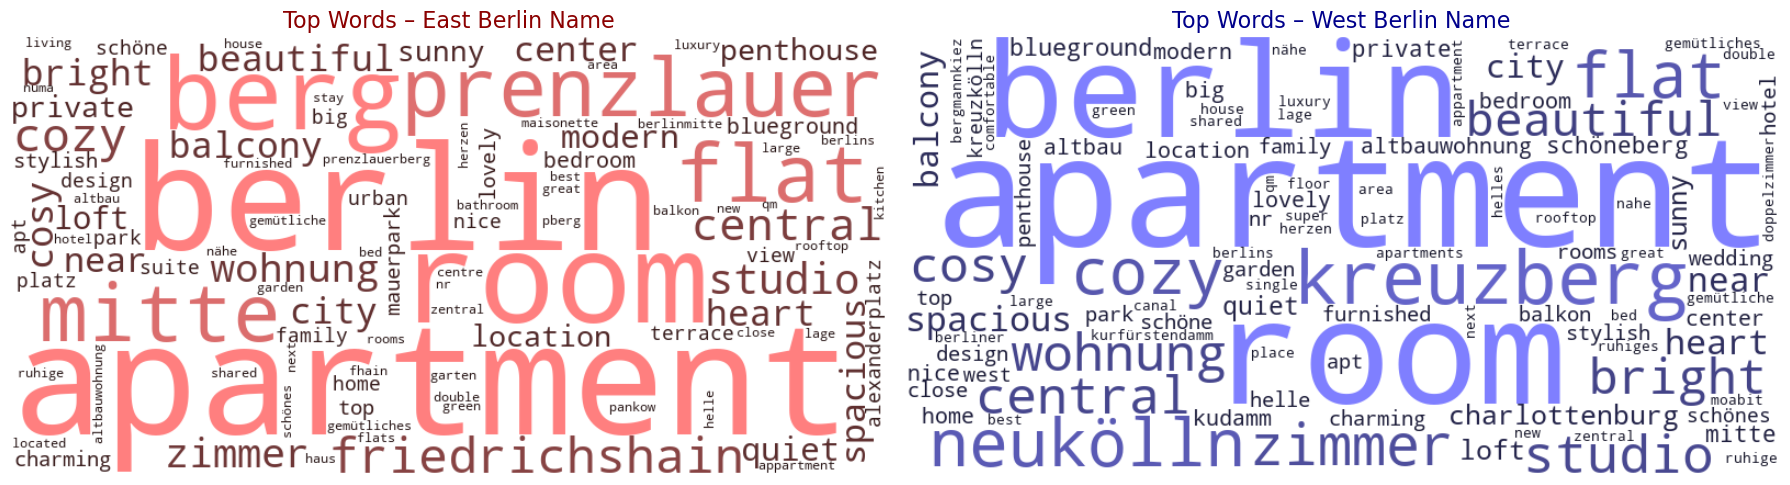

In [65]:
# Step 1: Convert word frequencies to dictionaries
east_freq_dict = east_counts[0].to_dict()
west_freq_dict = west_counts[0].to_dict()

# Step 2: Custom color functions
def red_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    # Bigger = darker red
    red = min(255, font_size * 3)
    return f"rgb({red}, {int(red*0.5)}, {int(red*0.5)})"

def blue_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    # Bigger = darker blue
    blue = min(255, font_size * 3)
    return f"rgb({int(blue*0.5)}, {int(blue*0.5)}, {blue})"

# Step 3: Generate word clouds
wc_east = WordCloud(width=800, height=400, background_color='white',
                    color_func=red_color_func,max_words=100).generate_from_frequencies(east_freq_dict)

wc_west = WordCloud(width=800, height=400, background_color='white',
                    color_func=blue_color_func,max_words=100).generate_from_frequencies(west_freq_dict)

# Step 4: Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

ax1.imshow(wc_east, interpolation='bilinear')
ax1.set_title("Top Words – East Berlin Name", fontsize=16, color='darkred')
ax1.axis('off')

ax2.imshow(wc_west, interpolation='bilinear')
ax2.set_title("Top Words – West Berlin Name", fontsize=16, color='darkblue')
ax2.axis('off')

plt.tight_layout()
plt.show()
# Save the combined figure
fig.savefig("berlin_wordclouds_east_vs_west_name.png", dpi=300, bbox_inches='tight')

In [66]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# Download VADER if not already
nltk.download('vader_lexicon')

# Step 1: Initialize the analyzer
sia = SentimentIntensityAnalyzer()

# Step 2: Compute sentiment score for each review
df['sentiment_na'] = df['na_clean_str'].apply(lambda x: sia.polarity_scores(x)['compound'])

# Step 3: Filter by region
east_na = df[df['region'] == 'East Berlin']
west_na = df[df['region'] == 'West Berlin']

east_na = east_na.drop_duplicates(subset='name')
west_na = west_na.drop_duplicates(subset='name')

most_positive_east = east_na.sort_values(by='sentiment_na', ascending=False).head(5)
most_negative_east = east_na.sort_values(by='sentiment_na').head(5)

most_positive_west = west_na.sort_values(by='sentiment_na', ascending=False).head(5)
most_negative_west = west_na.sort_values(by='sentiment_na').head(5)

# Step 5: Display Results
def print_top_no(df_subset, title):
    print(f"\n{title}")
    print("-" * 60)
    for i, row in df_subset.iterrows():
        print(f"Name: {row['name']}")
        print(f"Sentiment Score: {row['sentiment_na']}")
        print("-" * 60)

# East
print_top_no(most_positive_east, "Top 5 Positive Name – East")
print_top_no(most_negative_east, "Top 5 Negative Name – East")

# West
print_top_no(most_positive_west, "Top 5 Positive Name – West")
print_top_no(most_negative_west, "Top 5 Negative Name – West")


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\mc127\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!



Top 5 Positive Name – East
------------------------------------------------------------
Name: Charming, peaceful and lovingly refurbished Altbau
Sentiment Score: 0.9042
------------------------------------------------------------
Name: Charming sunny flat with a great view and balcony
Sentiment Score: 0.8934
------------------------------------------------------------
Name: Perfect central location - bright, beautiful space
Sentiment Score: 0.8885
------------------------------------------------------------
Name: Charming flat created with love
Sentiment Score: 0.875
------------------------------------------------------------
Name: Nice room in vibrant friendly Friedrichshain
Sentiment Score: 0.8555
------------------------------------------------------------

Top 5 Negative Name – East
------------------------------------------------------------
Name: Hell und ruhig in der Natur
Sentiment Score: -0.6808
------------------------------------------------------------
Name: Sehr hell
Sen

In [67]:
# Select relevant columns for the summary table
cols_to_show = ['name', 'sentiment_na', 'review_scores_rating','price']

# Round sentiment scores for readability
most_positive_east['sentiment_na'] = most_positive_east['sentiment_na']
most_negative_east['sentiment_na'] = most_negative_east['sentiment_na']
most_positive_west['sentiment_na'] = most_positive_west['sentiment_na']
most_negative_west['sentiment_na'] = most_negative_west['sentiment_na']

# Display tables
print("Top 5 Positive – East Berlin")
display(most_positive_east[cols_to_show].reset_index(drop=True))

print("Top 5 Negative  – East Berlin")
display(most_negative_east[cols_to_show].reset_index(drop=True))

print("Top 5 Positive  – West Berlin")
display(most_positive_west[cols_to_show].reset_index(drop=True))

print("Top 5 Negative  – West Berlin")
display(most_negative_west[cols_to_show].reset_index(drop=True))

Top 5 Positive – East Berlin


,name,sentiment_na,review_scores_rating,price
0,"Charming, peaceful and lovingly refurbished Al...",0.9042,4.92,$152.00
1,Charming sunny flat with a great view and balcony,0.8934,4.95,$115.00
2,"Perfect central location - bright, beautiful s...",0.8885,5.00,NaN
3,Charming flat created with love,0.8750,4.91,$130.00
4,Nice room in vibrant friendly Friedrichshain,0.8555,5.00,NaN


Top 5 Negative  – East Berlin


,name,sentiment_na,review_scores_rating,price
0,Hell und ruhig in der Natur,-0.6808,NaN,$56.00
1,Sehr hell,-0.6808,NaN,NaN
2,Ruhig Hell Wohnen im Grünen füßläufig zum Wasser,-0.6808,4.71,$105.00
3,"Wunderschön, hell und groß",-0.6808,4.88,$210.00
4,"Berlin Central/Mitte, 110 m², hell, grün",-0.6808,5.00,NaN


Top 5 Positive  – West Berlin


,name,sentiment_na,review_scores_rating,price
0,Charming Beautiful apartment in great location !,0.9153,NaN,NaN
1,huge and sunny room great location nice roommates,0.9001,5.00,NaN
2,Bright and charming flat with perfect connection,0.8860,4.00,NaN
3,Cute & Clever option. BEST AREA,0.8807,4.79,NaN
4,relaxing sunny room in amazing Neukolln,0.8689,4.80,NaN


Top 5 Negative  – West Berlin


,name,sentiment_na,review_scores_rating,price
0,ruhiges Doppelzimmer nah der FU & US Botschaft,-0.7269,4.88,$46.00
1,Helles Doppelzimmer nah der FU & US Botschaft,-0.7269,4.78,$50.00
2,Kreuzberger Perle - Hell und nah am Wasser,-0.7184,5.00,$197.00
3,"Private Room in a house, near FU and metro",-0.6908,4.97,$23.00
4,Exklusive Altbau-Wohnung Nähe FU,-0.6908,NaN,$64.00


In [68]:
from shapely import wkt

df['geometry'] = df['geometry'].apply(wkt.loads)

import geopandas as gpd
from shapely.geometry import Point


df_gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')  

print(type(df_gdf))
print(df_gdf.geometry.head())
# this file is now ready to be plot
# still need other base layers as map of berlin
print(type(df_gdf))
print(df_gdf.geometry.head())
# this file is now ready to be plot
# still need other base layers as map of berlin

dividing_line = geopandas.read_file(data_dir+"/dividing_line.json")
east_berlin = geopandas.read_file(data_dir+"/east_berlin.json")
west_berlin = geopandas.read_file(data_dir+"/west_berlin.json")

<class 'geopandas.geodataframe.GeoDataFrame'>
0     POINT (13.4181 52.53471)
1    POINT (13.41805 52.53269)
2    POINT (13.40366 52.54813)
3    POINT (13.43508 52.50312)
4    POINT (13.42166 52.49419)
Name: geometry, dtype: geometry
<class 'geopandas.geodataframe.GeoDataFrame'>
0     POINT (13.4181 52.53471)
1    POINT (13.41805 52.53269)
2    POINT (13.40366 52.54813)
3    POINT (13.43508 52.50312)
4    POINT (13.42166 52.49419)
Name: geometry, dtype: geometry


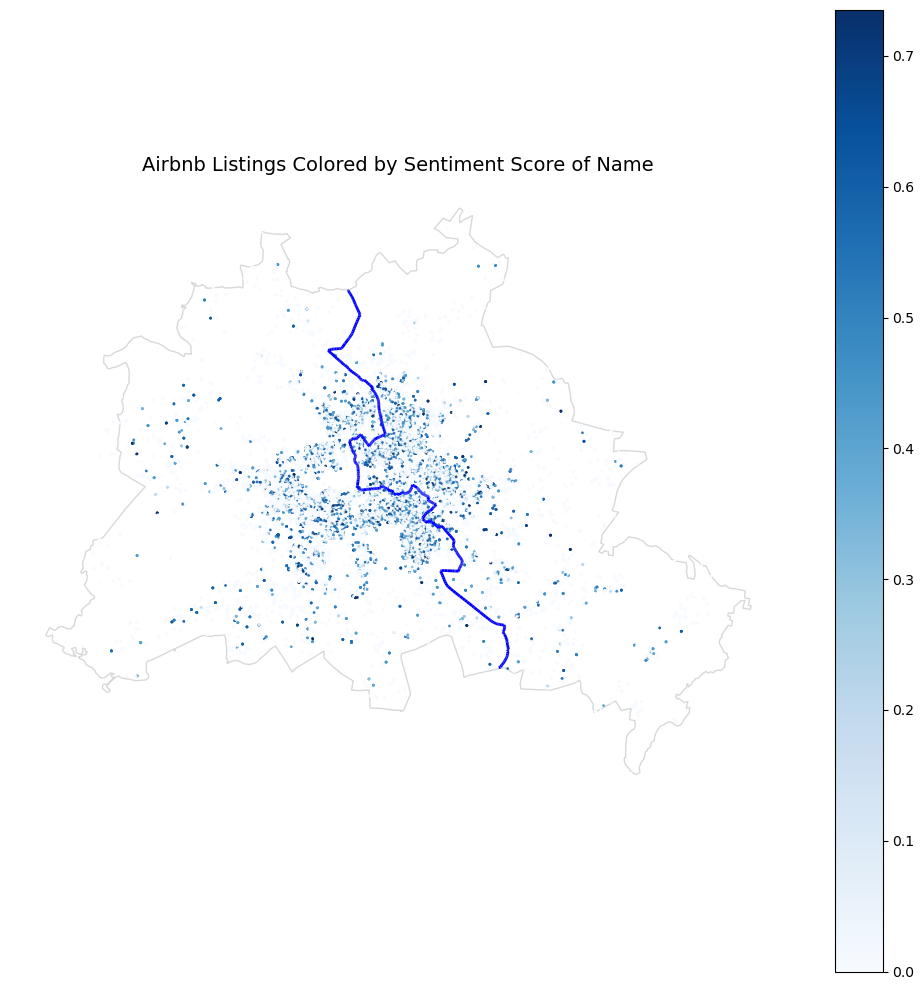

In [69]:
fig, ax = plt.subplots(figsize=(10, 10))

east_berlin.plot(ax=ax, facecolor='white', edgecolor='grey', alpha=0.3)
west_berlin.plot(ax=ax, facecolor='white', edgecolor='grey', alpha=0.3)
dividing_line.plot(ax=ax, color='blue', linewidth=2)

# Normalize sentiment if needed
vmin = df_gdf['sentiment_na'].quantile(0.02)
vmax = df_gdf['sentiment_na'].quantile(0.98)

# Plot sentiment scores
df_gdf.plot(
    ax=ax,
    column='sentiment_na',
    cmap='Blues',       
    markersize=1,
    legend=True,
    alpha=0.8,
    vmin=vmin,
    vmax=vmax
)

ax.set_title("Airbnb Listings Colored by Sentiment Score of Name", fontsize=14)
ax.axis("off")
plt.tight_layout()

plt.savefig("airbnb_sentiment_map_name.png", dpi=300, bbox_inches='tight')
plt.show()

In [70]:
# Clean price column
df['price_clean'] = df['price'].replace('[\$,]', '', regex=True).astype(float)

# Now create a DataFrame with just the relevant columns
price_and_amm = df[['sentiment_na', 'price_clean']]

# Compute correlation matrix
correlation_matrix = price_and_amm.corr()
print(correlation_matrix)

              sentiment_na  price_clean
sentiment_na      1.000000     0.012137
price_clean       0.012137     1.000000


<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
C:\Users\mc127\AppData\Local\Temp\ipykernel_55332\3352619390.py:2: SyntaxWarning: invalid escape sequence '\$'
  df['price_clean'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
